# 10 Sense chain, board against board

A sense chain is the shunt, the amplifier, the terminal dividers and the ADC that turn a
current and two terminal voltages into counts. The way to grade one is a session with a
resistor grid on the motor terminals and a multimeter on the same nodes. A resistor has no
back-EMF, no brushes and no commutator, and at 100% duty the bridge stops switching, so the
meter and the chip read the same DC quantity and any disagreement belongs to the chain.

Board D's measured chain figures in `oscnb/boards.py` come from that session. The rev-2A board
is meant to fix what it found, so this notebook runs the same measurements for any grid
dataset, picks the board from each recording's own `sense` block, and prints one table at the
end with a column per dataset. Nothing in here names a board.

If you only want the short version:

- Board D: VDD 3.28 V, the terminal chain within 0.44% of the meter's band,
  the current chain about 1% high with a 3% bracket, an honest crest current from 15% duty
  on 2S, and a shunt edge that settles 4.3 us after the ON edge.
- Rev 2A is better where it was meant to be. The crest reading is honest from 7% duty on
  2S, and the 7% floor is the tap A sample, the current itself already reads 97% of its
  plateau at 5%. The shunt edge settles in 3.2 us, and the rest current noise is 1.3 counts
  against board D's 1.7.
- The 2A current chain is accurate to about 1%. The grid session has no DC laps, so the
  check is a lap with the meter across Rs1: 93 to 94 mV on the meter against 93.3 to 95.1 mV
  from the chip's current times the nominal shunt, median 94.0. The load route of section 5.1
  reads 5.0% high only because it leans on the meter's ohms range at J4.
- Board #1 of rev 2A had an open Rv3 for this session, so its tap B reads the bias node
  instead of terminal B. Section 2 says how the notebook copes with that, and what it costs.
  Rv3 is repaired, and a 2A dataset captured with it fitted takes the two-tap route with no
  change here.
- Section 8 derives the drive window floors from the scan geometry. The 2A current reads inside 1%
  of its 100% rung from a 119 to 125 tick window and inside 3% from the lowest rung, 60 ticks. The
  shipped floors are notebook 16's, 64 ticks for the current with a settle gain on top and 93 for
  the terminals with tap B sampled early, so section 8.5's 132 and 160 are superseded.
- Section 9 grades the current reading on board #1's final amplifier network, on a stalled
  MG90 and a 15.3 ohm resistor. The chain reads the resistor within 0.6% from a 48-tick window,
  the motor's own 2% floor is 54 to 58 ticks at worst, and the shipped settle gain now
  over-reads by 3.6 to 4.1% at the 64-tick floor.

## 1. The datasets

Each grid dataset is one board on one supply with the 3.7 ohm grid on the motor terminals.
The load row is what the meter read for that session and where, because the grid's cable and
contacts are part of the path the board sees: 3.7 ohm at the grid's own header on board D,
4.4 ohm at J4 on rev 2A.
The board is not declared anywhere. It comes from the first recording's `sense` block, and
reading any other recording checks its block against the same entry, so a dataset that mixes
two boards fails at load.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import oscnb

Q15 = 32767

# Every grid session this notebook knows how to grade. A dataset that has not been captured
# yet is reported and skipped, so the rev-2A column appears the day its folder lands.
GRIDS = [
    "grid-3r7__dev-v006-D__2s",
    "grid-3r7__dev-v006-D__usb",
    "grid-3r7__dev-v006-2A__2s",
]
FOUND = oscnb.datasets.find()
GDS = {k: FOUND[k] for k in GRIDS if k in FOUND}
for k in GRIDS:
    if k not in FOUND:
        print(f"{k}: not captured yet, skipped")

# Short column labels: the board key the sense block picked, plus the supply.
LABEL = {k: f"{d.board.key} {d.supply}" for k, d in GDS.items()}

# What each board's parts make of one count, straight off the registry entry.
pd.DataFrame({
    LABEL[k]: {
        "drive rule": d.rule,
        "shunt [mOhm]": d.board.shunt_mohm,
        "amplifier gain": d.board.amp_gain,
        "current [counts per A]": round(d.board.counts_per_a, 1),
        "terminal divider ratio r": round(d.board.div_ratio, 4),
        "terminal [mV per count]": round(d.board.v_term_per_count * 1e3, 3),
        "VB nominal [counts]": round(d.board.vb_nom_counts, 1),
        "rail tap ratio": d.board.vbus_ratio,
        "load [ohm]": d.load.value,
        "load measured at": d.decl["load"]["where"] if "load" in d.decl else "grid header pins",
    } for k, d in GDS.items()})

,dev-v006-D 2s,dev-v006-D usb,dev-v006-2A 2s
drive rule,free,free,limit
shunt [mOhm],60,60,60
amplifier gain,15.0,15.0,14.884
current [counts per A],1117.1,1117.1,1108.5
terminal divider ratio r,3.0606,3.0606,5.0
terminal [mV per count],2.466,2.466,4.028
VB nominal [counts],779.4,779.4,772.8
rail tap ratio,2.5,2.5,5.0
load [ohm],3.7,3.7,4.4
load measured at,grid header pins,grid header pins,J4 board terminals


## 2. Reading a recording

Three rules apply to every recording below, and they are the only places where the two boards
could need different handling.

**When a rung counts as settled.** Board D was captured before the servo limited open-loop
current, so every rung stepped straight to its duty. A rev-2A capture runs under the current
limit, which raises the duty from the window floor at about 0.4% per tick, so a rung from rest
to 100% takes about 11 ms to arrive. A rung counts from the first sample where the applied
duty reaches its held value, and never earlier than 40 samples (2 ms) after it opens, which is
the settle the board D sweep notebooks use for the rail and the taps. On board D the applied duty arrives in
one or two samples, so the 2 ms rule is the one that binds and nothing changes.

**Which terminal is high.** A rung drives terminal A high when tap A reads above tap B. On
board D that is the same as positive duty. It does not depend on the drive polarity setting.

**Whether tap B is a terminal.** A working tap B swings by hundreds of counts when its
terminal drives. Board #1 of rev 2A has Rv3 open, so nothing connects tap B to terminal B and
the 1k6 bottom leg ties it to the bias node. That tap reads $V_B$ itself, live, including the
rise the bias node takes under drive. So on a board like that the notebook uses tap A alone,
on rungs where A is the high side, and converts it with tap B as the bias:

$$V_A = r\,\text{tap}_A - (r - 1)\,\text{tap}_B .$$

What tap A alone cannot see is the low side. The load sees $V_A - V_B$, and $V_B$ on the
driven-low terminal is the current times the low-side switch, the shunt and the copper, about
0.45 V at 1.7 A on board D. So on the tap-A route an apparent resistance carries that path
too, and a terminal reading graded against the meter has to be graded against the meter on
MOT_A to ground, not across the grid. A ratio of two rungs still cancels it, because the low
side is ohmic and scales with the same current. The reverse laps, where A is the low side,
measure that path on the A side directly.

In [2]:
SKIP_SAMPLES = 40    # 2 ms after a rung opens, for the rail and the taps to settle
FRAMES = {}


def frame(rec):
    # rec.frame() checks the recording's sense block and drive rule against its dataset.
    # Cached, because several sections read the same ladders.
    if str(rec) not in FRAMES:
        FRAMES[str(rec)] = rec.frame()
    return FRAMES[str(rec)]


def settled(g):
    # The applied duty this rung held, from its second half, then the first sample that
    # reached it. Under the limit rule that is the end of the climb from the window floor.
    held = g["duty_q15"].iloc[len(g) // 2:].median()
    at = np.flatnonzero(g["duty_q15"].to_numpy() == held)
    return g.iloc[max(SKIP_SAMPLES, at[0] if len(at) else len(g)):]


def tap_b_is_terminal(d):
    # Largest rise of tap B over its own rest reading, across the first ladder capture.
    swing = 0.0
    cap = d.captures("ladder")[0]
    for rec in d.recordings("ladder", cap):
        df = frame(rec)
        rest = df[df["seg"] == 0]["vmotor_b"].median()
        swing = max(swing, (df[df["seg"] > 0].groupby("seg")["vmotor_b"].median() - rest).max())
    return swing > 200


ROUTE = {k: ("ab" if tap_b_is_terminal(d) else "a") for k, d in GDS.items()}

# The meter log of each session, and VDD from it. VDD is the ADC reference, so every absolute
# volt and amp scales with it. K_VDD is applied wherever an absolute number is quoted and
# nowhere a ratio of two readings off the same chain is.
def meter(d):
    p = d.path / "dclap" / "dmm.csv"
    return pd.read_csv(p, dtype={"lap": str}) if p.exists() else None


K_VDD, VDD = {}, {}
for k, d in GDS.items():
    m = meter(d)
    row = m[(m["lap"] == "setup") & m["where"].str.startswith("VDD")] if m is not None else []
    VDD[k] = float(row["v_lo"].iloc[0]) if len(row) else np.nan
    K_VDD[k] = VDD[k] / (d.board.vdd_mv / 1e3) if len(row) else 1.0

CARD = {k: {} for k in GDS}
for k, d in GDS.items():
    CARD[k]["terminal route"] = "taps A and B" if ROUTE[k] == "ab" else "tap A, tap B reads VB"
    CARD[k]["VDD by meter [V]"] = VDD[k]
    vdd = (f"VDD {VDD[k]:.3f} V by meter" if np.isfinite(VDD[k])
           else f"VDD not metered, the declared {d.board.vdd_mv / 1e3:.3f} V")
    print(f"{LABEL[k]:<20} {CARD[k]['terminal route']:<24} {vdd}, "
          f"absolute numbers scaled by {K_VDD[k]:.5f}")

dev-v006-D 2s        taps A and B             VDD 3.280 V by meter, absolute numbers scaled by 0.99394
dev-v006-D usb       taps A and B             VDD 3.280 V by meter, absolute numbers scaled by 0.99394
dev-v006-2A 2s       tap A, tap B reads VB    VDD not metered, the declared 3.300 V, absolute numbers scaled by 1.00000


### 2.1 Capture method and integrity

Every number below is a mean over samples, so a missing sample only matters if there are many
of them. Whether there are is provable from the data, because of how a capture is taken.

- The servo streams every sample at the control rate with its tick counter, 16 samples to a
  frame with a CRC. A corrupted frame is dropped whole, so corruption turns into missing
  samples, and a dropped frame shows as a jump in the tick column, 16 ticks for one frame.
- A capture in which the host counted a dropped frame is re-run, not patched.
- Every recording opens with a torque-off rest segment, segment 0, and carries its own baselines from it, the current amplifier's offset (the mean of `current_raw`) and the bias
  node $V_B$ on each tap (the median of `vmotor_a` and `vmotor_b`). Nothing pools those across
  recordings, so a session that drifted cannot leak its offset into another.
- The servo duty sweeps that notebooks 01 to 08 read were taken with a reboot and a rest
  between captures, and with the first capture of each experiment discarded as a warm-up, so
  every kept capture starts from the same software state and a similar thermal state.

The cell below counts the gaps inside each segment and sizes them in frames, next to the rows
the servo itself reported dropping when it wrote the recording. It covers the grid sessions of
this notebook and every experiment of the two SG90 datasets on board D, the ones notebooks 01
to 08 read. For those it reads only the segment and tick columns, since a count needs nothing
else, and the notebooks that use the values check each recording's `sense` block as they load
it.

In [3]:
rows = []


GAP_AT = []


def gaps(df, where):
    # Tick steps inside each segment that are not 1, as missing samples per gap.
    step = df.groupby("seg")["tick"].diff().dropna()
    bad = step[step != 1]
    GAP_AT.extend(f"{where} seg {int(df.loc[i, 'seg'])}: {int(n) - 1} samples" for i, n in bad.items())
    return (bad - 1).astype(int).tolist()


for k, d in GDS.items():
    for exp in [e for e in ("ladder", "dclap") if e in d.experiments]:
        for cap in d.captures(exp):
            for rec in d.recordings(exp, cap):
                g = gaps(frame(rec), f"{LABEL[k]} {exp}/{cap}/{rec.name}")
                rows.append({"dataset": LABEL[k], "experiment": exp, "samples": len(frame(rec)),
                             "gaps": len(g), "missing": sum(g),
                             "whole frames": all(n % 16 == 0 for n in g),
                             "rows dropped (servo)": rec.meta.get("rows_dropped", 0)})

# The SG90 duty-sweep datasets on board D, every experiment.
for name in ("sg90-a__dev-v006-D__2s", "sg90-a__dev-v006-D__usb"):
    d = oscnb.datasets.load(name)
    for exp in d.experiments:
        for cap in d.captures(exp):
            for rec in d.recordings(exp, cap):
                df = pd.read_csv(rec.path, usecols=["seg", "tick"])
                g = gaps(df, f"{name} {exp}/{cap}/{rec.name}")
                rows.append({"dataset": f"sg90-a {d.board.key} {d.supply}", "experiment": exp,
                             "samples": len(df), "gaps": len(g), "missing": sum(g),
                             "whole frames": all(n % 16 == 0 for n in g),
                             "rows dropped (servo)": rec.meta.get("rows_dropped", 0)})

INTEGRITY = pd.DataFrame(rows).groupby(["dataset", "experiment"]).agg(
    recordings=("samples", "size"), samples=("samples", "sum"), gaps=("gaps", "sum"),
    missing_samples=("missing", "sum"), whole_frames=("whole frames", "all"),
    rows_dropped=("rows dropped (servo)", "sum"))
print(INTEGRITY.to_string())

                                       recordings  samples  gaps  missing_samples  whole_frames  rows_dropped
dataset               experiment                                                                             
dev-v006-2A 2s        ladder                   10   295584     1              416          True             0
dev-v006-D 2s         ladder                   10   266000     0                0          True             0
dev-v006-D usb        ladder                    3    86000     0                0          True             0
sg90-a dev-v006-D 2s  adccheck                  1    25600     0                0          True             0
                      breakaway                 5   820000     0                0          True             0
                      bridge                   15  4044000     0                0          True             0
                      grid                     10  3368000     0                0          True             0
          

In [4]:
# The one line the reader needs from the table above.
for ds_label, t in INTEGRITY.groupby(level="dataset"):
    print(f"{ds_label:<26} {int(t['recordings'].sum()):>4} recordings, "
          f"{int(t['samples'].sum()):>9} samples, {int(t['gaps'].sum())} gaps, "
          f"{int(t['missing_samples'].sum())} missing samples")
sg = INTEGRITY.loc[[i for i in INTEGRITY.index if i[0].startswith("sg90-a")]]
print(f"\nthe SG90 sweeps on board D: {int(sg['recordings'].sum())} recordings, "
      f"{int(sg['samples'].sum())} samples, {int(sg['gaps'].sum())} gaps")
for g in GAP_AT:
    print(f"gap at {g} ({int(g.split(': ')[1].split()[0]) / 16:g} frames)")

dev-v006-2A 2s               10 recordings,    295584 samples, 1 gaps, 416 missing samples
dev-v006-D 2s                10 recordings,    266000 samples, 0 gaps, 0 missing samples
dev-v006-D usb                3 recordings,     86000 samples, 0 gaps, 0 missing samples
sg90-a dev-v006-D 2s         71 recordings,   9748400 samples, 0 gaps, 0 missing samples
sg90-a dev-v006-D usb       104 recordings,  17944200 samples, 0 gaps, 0 missing samples

the SG90 sweeps on board D: 175 recordings, 27692600 samples, 0 gaps
gap at dev-v006-2A 2s ladder/capture-3/top seg 0: 416 samples (26 frames)


Every recording the board D notebooks read is whole, with no gap in any experiment of either SG90
dataset or either board D grid session. The rev-2A grid session has one gap, 416 samples or 26
whole frames, inside the torque-off rest of ladder capture-3's `top` recording, and the servo
reported no dropped rows for that recording. Section 3 takes its rest figures from the `ladder`
recordings only, so the gap enters no number in this notebook. A loss the servo did not count
is still a loss, and it is listed in section 9.

## 3. At rest

The torque-off baseline that opens every ladder capture. A static load has no shaft ringing
down, so the whole second counts. The bias node reads directly on both taps here, because with
the bridge off no current flows through either divider.

The current channel's standard deviation here is the noise a single crest sample carries. It
is not the 2.2 counts the registry quotes as board D's amplifier floor, which came from a
bringup bench run with the amplifier on its own, so the two sit in separate rows below.

In [5]:
REST = {}
for k, d in GDS.items():
    b, kv = d.board, K_VDD[k]
    caps = d.captures("ladder")
    base = [frame(r)[lambda x: x["seg"] == 0] for c in caps
            for r in d.recordings("ladder", c) if r.name == "ladder"]
    sd = pd.DataFrame([g[["current_raw", "vmotor_a", "vmotor_b", "vbus_raw"]].std() for g in base]).mean()
    mean = pd.DataFrame([g[["current_raw", "vmotor_a", "vmotor_b", "vbus_raw"]].mean() for g in base]).mean()
    # Bus-coupling check: rest current binned by position in the 16-sample telemetry frame.
    by = base[0].groupby(base[0]["tick"] % 16)["current_raw"].mean()
    c = CARD[k]
    c["VB rest, tap A [counts]"] = mean["vmotor_a"]
    c["VB rest, tap B [counts]"] = mean["vmotor_b"]
    c["VB nominal [counts]"] = b.vb_nom_counts
    c["VB rest, tap A [mV]"] = mean["vmotor_a"] * b.v_adc_per_count * kv * 1e3
    m = meter(d)
    vb = m[(m["lap"] == "setup") & m["where"].str.startswith("VB")] if m is not None else []
    c["VB by meter [mV]"] = float(vb["v_lo"].iloc[0]) * 1e3 if len(vb) else np.nan
    c["rest current sd [counts]"] = sd["current_raw"]
    c["rest current sd [mA]"] = sd["current_raw"] * b.a_per_count * kv * 1e3
    c["rest tap A sd [mV at the terminal]"] = sd["vmotor_a"] * b.v_term_per_count * kv * 1e3
    c["rest rail sd [mV]"] = sd["vbus_raw"] * b.v_adc_per_count * b.vbus_ratio * kv * 1e3
    c["frame-position spread [counts]"] = by.max() - by.min()
    REST[k] = len(base)

pd.DataFrame({LABEL[k]: {q: v for q, v in CARD[k].items() if q.startswith(("VB", "rest", "frame"))}
              for k in GDS}).round(3)

,dev-v006-D 2s,dev-v006-D usb,dev-v006-2A 2s
"VB rest, tap A [counts]",779.168,779.059,769.780
"VB rest, tap B [counts]",783.146,783.023,771.034
VB nominal [counts],779.401,779.401,772.830
"VB rest, tap A [mV]",623.943,623.856,620.184
VB by meter [mV],NaN,NaN,NaN
rest current sd [counts],1.697,1.902,1.275
rest current sd [mA],1.510,1.692,1.151
rest tap A sd [mV at the terminal],2.009,1.802,3.458
rest rail sd [mV],4.336,3.403,3.768
frame-position spread [counts],0.586,0.636,0.854


## 4. DC laps against the meter

A DC lap holds 100% duty for a few seconds while the meter sits on one node, and at 100% the
bridge does not switch at all, so the meter and the chip read the same DC quantity. Board D's
laps were polled once a second and typed into `dclap/chip.csv` by hand. The rev-2A laps are
`osc sweep` recordings under `dclap/capture-N`, one lap each, so the lap number is the capture
number and the chip side is the full-rate stream. Both end up in the same per-lap table.

A lap is left out when no current flowed (the meter's dead 10 A jack on board D opened the
loop) or when the applied duty fell to zero during the hold (a brown-out reboot).

The meter log names where the probes were. Each name maps to the quantity it grades:

| meter row | graded against |
|---|---|
| `OUTA-OUTB pads [V]`, `MOT_A-MOT_B at J4 [V]` | the terminal difference, both taps |
| `grid header pins [V]` | the terminal difference, and the current as volts over the grid |
| `MOT_A to GND [V]` | tap A alone, absolute |
| `VSYS to GND [V]` | the rail tap under load |
| `10 A jack in series at the grid header [A]` | the current, directly |
| `Rs1 pads [mV]` | the amplifier gain alone, current times nominal shunt cancels |
| `VB at Cb1 to GND [V]` | in setup, the rest taps; during a lap, a tap B that reads the bias node |

In [6]:
KIND = {"OUTA-OUTB pads [V]": "pads", "MOT_A-MOT_B at J4 [V]": "pads",
        "grid header pins [V]": "grid", "MOT_A to GND [V]": "tap_a", "VSYS to GND [V]": "rail",
        "10 A jack in series at the grid header [A]": "ammeter", "Rs1 pads [mV]": "shunt_mv", "VB at Cb1 to GND [V]": "vb"}
COLS = ["vmotor_a", "vmotor_b", "current", "vbus_raw"]


def laps_polled(d):
    # Board D: one printed row per second, t_s 0 is the rest line before the drive.
    chip = pd.read_csv(d.path / "dclap" / "chip.csv", dtype={"lap": str})
    chip = chip[chip["supply"] == d.supply]
    out = []
    for (lap, duty), g in chip.groupby(["lap", "duty_pct"], sort=False):
        rest = g[g["t_s"] == 0].iloc[0]
        hold = g[(g["t_s"] > 0) & (g["duty_applied_q15"].abs() > 0)].dropna(subset=COLS)
        if not len(hold):
            continue
        out.append({"lap": lap, "duty_pct": duty, "seconds": len(hold),
                    "cut": bool((g[g["t_s"] > 0]["duty_applied_q15"] == 0).any()),
                    **{f"rest_{c}": rest[c] for c in COLS}, **hold[COLS].mean().to_dict()})
    return out


def laps_streamed(d):
    # Rev 2A: one sweep recording per lap, seg 0 the torque-off rest, the rest the hold.
    out = []
    for cap in d.captures("dclap"):
        df = frame(d.recordings("dclap", cap)[0]).rename(columns={"current_raw": "current"})
        rest = df[df["seg"] == 0]
        hold = pd.concat([settled(g) for _, g in df[df["seg"] > 0].groupby("seg")])
        out.append({"lap": cap.split("-")[1],
                    "duty_pct": round(hold["cmd_duty_q15"].iloc[0] * 100 / Q15),
                    "seconds": len(hold) / d.board.tick_hz,
                    "cut": bool((hold["duty_q15"] == 0).any()),
                    **{f"rest_{c}": rest[c].mean() for c in COLS}, **hold[COLS].mean().to_dict()})
    return out


LAP_COLS = ["lap", "duty_pct", "A high", "seconds", "rail_rest_V", "rail_load_V", "high_side_V",
            "low_side_V", "terminal_A_V", "terminal_diff_V", "tap_B_V", "amps_A", "hs_drop_V",
            "R_app_ohm", "used"]


def lap_table(k, d):
    b, kv = d.board, K_VDD[k]
    if "dclap" in d.experiments:
        raw = laps_streamed(d)
    elif (d.path / "dclap" / "chip.csv").exists():
        raw = laps_polled(d)
    else:
        raw = []
    rows = []
    for L in raw:
        a_high = L["vmotor_a"] > L["vmotor_b"]
        amps = abs(b.amps(L["current"], L["rest_current"])) * kv
        if ROUTE[k] == "ab":
            # Each terminal through its own rest tap as VB, the difference bias free.
            hi, lo = ("vmotor_a", "vmotor_b") if a_high else ("vmotor_b", "vmotor_a")
            v_hi = b.term_v(L[hi], L[f"rest_{hi}"]) * kv
            v_lo = b.term_v(L[lo], L[f"rest_{lo}"]) * kv
            v_a = b.term_v(L["vmotor_a"], L["rest_vmotor_a"]) * kv
            diff = abs(b.diff_v(L["vmotor_a"], L["vmotor_b"])) * kv
            load_v = diff
        else:
            # Tap B is the live bias node, so it is the VB tap A converts against.
            v_a = b.term_v(L["vmotor_a"], L["vmotor_b"]) * kv
            v_hi, v_lo = (v_a, np.nan) if a_high else (np.nan, v_a)
            diff = np.nan
            load_v = v_a if a_high else np.nan     # includes the unseen low side
        rail_load = b.vsys_v(L["vbus_raw"]) * kv
        rows.append({"lap": L["lap"], "duty_pct": L["duty_pct"], "A high": a_high,
                     "seconds": L["seconds"],
                     "rail_rest_V": b.vsys_v(L["rest_vbus_raw"]) * kv, "rail_load_V": rail_load,
                     "high_side_V": v_hi, "low_side_V": v_lo, "terminal_A_V": v_a,
                     "terminal_diff_V": diff, "tap_B_V": L["vmotor_b"] * b.v_adc_per_count * kv, "amps_A": amps, "hs_drop_V": rail_load - v_hi,
                     "R_app_ohm": load_v / amps if amps > 0.05 else np.nan,
                     "used": amps > 0.05 and not L["cut"]})
    return pd.DataFrame(rows, columns=LAP_COLS).set_index("lap")


LAPS = {k: lap_table(k, d) for k, d in GDS.items()}
for k, t in LAPS.items():
    if len(t):
        print(LABEL[k])
        print(t.round(4).to_string(), "\n")
    else:
        print(f"{LABEL[k]}: no DC laps captured\n")

dev-v006-D 2s
     duty_pct  A high  seconds  rail_rest_V  rail_load_V  high_side_V  low_side_V  terminal_A_V  terminal_diff_V  tap_B_V  amps_A  hs_drop_V  R_app_ohm   used
lap                                                                                                                                                           
1         100    True        6       7.2030       6.8190       6.7077      0.4502        6.7077           6.2526   0.5682  1.6991     0.1113     3.6799   True
3         100    True        5       7.1830       7.1806       7.2914      0.0985        7.2914           7.1879   0.4532  0.0062    -0.1107        NaN  False
2         100    True        5       7.1750       6.7966       6.6886      0.4514        6.6886           6.2306   0.5686  1.7074     0.1080     3.6491   True
5        -100   False        5       7.1750       6.7918       6.5989      0.4590        0.4590           6.1448   2.5766  1.7030     0.1930     3.6083   True
6        -100   False        3  

### 4.1 Terminals and rail against the meter

The meter reading drifted while a human watched it, so the log carries a low and a high. The
fair comparison is the chip's mean against that band, with the midpoint as a second view.
Readings under 1 V (tap A on the low side) are listed in millivolts only, a percentage of a
few hundred millivolts says nothing about the chain's scale.

In [7]:
def against_meter(k, d):
    m, t = meter(d), LAPS[k]
    rows = []
    for _, r in (m if m is not None else pd.DataFrame(columns=["lap"])).iterrows():
        kind = KIND.get(r["where"])
        if r["lap"] not in t.index or not t.loc[r["lap"], "used"] or not np.isfinite(r["v_lo"]):
            continue
        L = t.loc[r["lap"]]
        chip = {"pads": L["terminal_diff_V"], "grid": L["terminal_diff_V"],
                "tap_a": L["terminal_A_V"], "rail": L["rail_load_V"], "vb": L["tap_B_V"]}.get(kind, np.nan)
        if not np.isfinite(chip):
            continue
        lo, hi = r["v_lo"], r["v_hi"]
        mid = (lo + hi) / 2
        edge = 0.0 if lo <= chip <= hi else (chip - lo if chip < lo else chip - hi)
        rows.append({"lap": r["lap"], "A high": L["A high"], "where": r["where"], "graded": kind,
                     "dmm_lo_V": lo, "dmm_hi_V": hi, "chip_V": chip,
                     "vs_midpoint_mV": (chip - mid) * 1e3,
                     "vs_band_pct": edge / mid * 100 if mid > 1 else np.nan,
                     "vs_midpoint_pct": (chip - mid) / mid * 100 if mid > 1 else np.nan})
    return pd.DataFrame(rows)


CMP = {}
for k, d in GDS.items():
    c = against_meter(k, d)
    CMP[k] = c
    term = c[c["graded"].isin(["pads", "grid", "tap_a"])] if len(c) else c
    rail = c[c["graded"] == "rail"] if len(c) else c
    CARD[k]["terminal vs meter, worst outside band [%]"] = term["vs_band_pct"].abs().max() if len(term) else np.nan
    CARD[k]["terminal vs meter, worst vs midpoint [%]"] = term["vs_midpoint_pct"].abs().max() if len(term) else np.nan
    CARD[k]["terminal vs meter, laps"] = int(term["vs_band_pct"].notna().sum()) if len(term) else 0
    CARD[k]["rail tap vs meter, worst vs midpoint [%]"] = rail["vs_midpoint_pct"].abs().max() if len(rail) else np.nan
    vbl = c[c["graded"] == "vb"] if len(c) else c
    CARD[k]["tap B vs meter VB during a lap [mV]"] = vbl["vs_midpoint_mV"].abs().max() if len(vbl) else np.nan
    if len(c):
        print(LABEL[k])
        print(c.round(4).to_string(index=False), "\n")
    else:
        print(f"{LABEL[k]}: " + ("no metered lap on this supply\n" if len(LAPS[k]) else "no DC laps captured\n"))

dev-v006-D 2s
lap  A high                where graded  dmm_lo_V  dmm_hi_V  chip_V  vs_midpoint_mV  vs_band_pct  vs_midpoint_pct
  1    True   OUTA-OUTB pads [V]   pads      6.28      6.31  6.2526        -42.4070      -0.4354          -0.6737
  2    True grid header pins [V]   grid      6.18      6.22  6.2306         30.6168       0.1712           0.4938
  5   False   OUTA-OUTB pads [V]   pads      6.14      6.19  6.1448        -20.1638       0.0000          -0.3271
  6   False   OUTA-OUTB pads [V]   pads      6.13      6.15  6.1517         11.6986       0.0277           0.1905
  8   False   OUTA-OUTB pads [V]   pads      6.11      6.16  6.1242        -10.7512       0.0000          -0.1752 

dev-v006-D usb: no metered lap on this supply

dev-v006-2A 2s: no DC laps captured



### 4.2 Current against the meter

Every current route is volts or amps from the meter set against the chip's current on the same
lap. Through the grid the route carries the grid's own 0.1 ohm last digit, 2.7% of 3.7 ohm,
which is the bracket board D could not get under because its meter's 10 A jack was dead. A
series ammeter takes the grid out of the loop.

The pad route reads upstream of the leads and clips, so their drop comes off first. That drop
is taken from the lap that metered the grid pins, as the chip's terminal difference minus the
meter there, and the pad route is only used in that lap's direction, because board D reads
less terminal voltage in reverse at the same current (section 4.4). The session log's hand pass
put the same drop at 0.04 V; the route below takes the measured 0.031 V.

The Rs1 route is different in kind. Millivolts across the shunt over its nominal 60 mOhm is
the current the amplifier was handed, so the chip's current over it is the amplifier gain over
its nominal value, with the shunt cancelled out.

In [8]:
METER_CLASS_PCT = 0.5     # the meter's own DC class, the same meter for every session

CUR, GAIN = {}, {}
for k, d in GDS.items():
    m, t = meter(d), LAPS[k]
    # The grid's own value at its header: the meter on the grid pins reads across exactly that.
    r_load = d.servo.measured["r_load"]
    grid_res_pct = (r_load.hi - r_load.lo) / 2 / r_load.value * 100
    rows = []
    rs = m[m["lap"].isin(t.index[t["used"].astype(bool)]) & m["v_lo"].notna()] if m is not None else pd.DataFrame(columns=["where", "lap"])
    rs = rs.assign(kind=rs["where"].map(KIND), mid=(rs["v_lo"] + rs["v_hi"]) / 2) if len(rs) else rs
    grid = rs[rs["kind"] == "grid"] if len(rs) and ROUTE[k] == "ab" else rs.iloc[:0]
    lead = np.mean([t.loc[r["lap"], "terminal_diff_V"] - r["mid"] for _, r in grid.iterrows()]) if len(grid) else np.nan
    # The lead drop is measured in the grid lap's direction only, so the pad route stays in it.
    lead_dir = set(t.loc[grid["lap"], "A high"]) if len(grid) else set()
    for _, r in rs.iterrows() if len(rs) else []:
        i_chip = t.loc[r["lap"], "amps_A"]
        if r["kind"] == "grid":
            i_m, why, br = r["mid"] / r_load.value, "volts at the grid pins over the grid", np.hypot(grid_res_pct, METER_CLASS_PCT)
        elif r["kind"] == "pads" and np.isfinite(lead) and t.loc[r["lap"], "A high"] in lead_dir:
            i_m, why, br = (r["mid"] - lead) / r_load.value, f"volts at the pads less {lead:.3f} V of leads, over the grid", np.hypot(grid_res_pct, METER_CLASS_PCT)
        elif r["kind"] == "ammeter":
            i_m, why, br = r["mid"], "series ammeter", METER_CLASS_PCT
        elif r["kind"] == "shunt_mv":
            g = i_chip / (r["mid"] / 1e3 / d.board.shunt_ohm)
            GAIN.setdefault(k, []).append({"lap": r["lap"], "Rs1_mV": r["mid"], "gain_over_nominal_pct": (g - 1) * 100})
            continue
        else:
            continue
        rows.append({"lap": r["lap"], "route": why, "I_meter_A": i_m, "I_chip_A": i_chip,
                     "error_pct": (i_chip / i_m - 1) * 100, "bracket_pct": br})
    CUR[k] = pd.DataFrame(rows)
    c = CARD[k]
    c["current vs meter, mean [%]"] = CUR[k]["error_pct"].mean() if len(rows) else np.nan
    c["current vs meter, bracket [%]"] = CUR[k]["bracket_pct"].min() if len(rows) else np.nan
    c["amplifier gain vs nominal [%]"] = pd.DataFrame(GAIN[k])["gain_over_nominal_pct"].mean() if k in GAIN else np.nan
    print(LABEL[k])
    print(CUR[k].round(4).to_string(index=False) if len(rows) else
          "  no current route metered on this supply" if len(t) else "  no DC laps captured")
    if k in GAIN:
        print(pd.DataFrame(GAIN[k]).round(3).to_string(index=False))
    print()

dev-v006-D 2s
lap                                                  route  I_meter_A  I_chip_A  error_pct  bracket_pct
  1 volts at the pads less 0.031 V of leads, over the grid     1.6931    1.6991     0.3581       2.7486
  2                   volts at the grid pins over the grid     1.6757    1.7074     1.8958       2.7486

dev-v006-D usb
  no current route metered on this supply

dev-v006-2A 2s
  no DC laps captured



### 4.3 Rail and low side

The rail tap reads at rest and under the lap's load, which gives the source impedance the
supply and its diodes present. The low side is the driven-low terminal on board D (both taps),
and tap A on the reverse laps of a tap-A board. That second one is the A-side low switch, the
shunt and the copper, which is the path the tap-A route cannot see on its forward laps.

In [9]:
for k, d in GDS.items():
    u = LAPS[k][LAPS[k]["used"].astype(bool)]
    c = CARD[k]
    c["rail at rest [V]"] = u["rail_rest_V"].mean() if len(u) else np.nan
    c["rail under the lap [V]"] = u["rail_load_V"].mean() if len(u) else np.nan
    c["source impedance [ohm]"] = ((u["rail_rest_V"] - u["rail_load_V"]) / u["amps_A"]).mean() if len(u) else np.nan
    c["lap current [A]"] = u["amps_A"].mean() if len(u) else np.nan
    lo = u["low_side_V"].dropna()
    c["low side at the lap current [V]"] = lo.mean() if len(lo) else np.nan
    c["low-side path [ohm]"] = (lo / u.loc[lo.index, "amps_A"]).mean() if len(lo) else np.nan
    if not len(u):
        print(f"{LABEL[k]:<20} no DC laps captured")
        continue
    print(f"{LABEL[k]:<20} rail {c['rail at rest [V]']:.3f} V at rest, {c['rail under the lap [V]']:.3f} V at "
          f"{c['lap current [A]']:.3f} A, {c['source impedance [ohm]']:.3f} ohm | low side "
          f"{c['low side at the lap current [V]']:.3f} V, {c['low-side path [ohm]']:.3f} ohm")

dev-v006-D 2s        rail 7.151 V at rest, 6.777 V at 1.692 A, 0.221 ohm | low side 0.451 V, 0.266 ohm
dev-v006-D usb       rail 4.892 V at rest, 4.537 V at 1.125 A, 0.316 ohm | low side 0.286 V, 0.254 ohm
dev-v006-2A 2s       no DC laps captured


### 4.4 Direction

The same 100% lap run both ways should read the same on a resistor. A grid cannot know which way
its current flows, and a low-side shunt sits in the return of both directions. So a
forward-to-reverse difference on the same load at the same current belongs to the board. This
pools every used lap per direction, on datasets with both taps and laps both ways. The pooled
numbers are ratios off one chain, so VDD cancels out of them.

In [10]:
DIRECTION = {}
for k, d in GDS.items():
    u = LAPS[k][LAPS[k]["used"].astype(bool)]
    if ROUTE[k] != "ab" or u["A high"].nunique() < 2:
        why = "no DC laps captured" if not len(LAPS[k]) else "no laps in both directions with both taps"
        print(f"{LABEL[k]:<20} {why}")
        continue
    f, r = u[u["A high"].astype(bool)], u[~u["A high"].astype(bool)]
    pct = lambda col: (r[col].mean() / f[col].mean() - 1) * 100
    DIRECTION[k] = {"laps forward": len(f), "laps reverse": len(r),
                    "terminal difference": pct("terminal_diff_V"), "current": pct("amps_A"),
                    "apparent resistance": pct("R_app_ohm"),
                    "high-side drop forward [V]": f["hs_drop_V"].mean(),
                    "high-side drop reverse [V]": r["hs_drop_V"].mean()}
    D = DIRECTION[k]
    print(f"{LABEL[k]:<20} {D['laps forward']} forward and {D['laps reverse']} reverse laps; reverse against forward: "
          f"terminal difference {D['terminal difference']:+.2f}%, current {D['current']:+.2f}%, "
          f"V/I {D['apparent resistance']:+.2f}% | high-side drop {D['high-side drop forward [V]']:.3f} V "
          f"forward, {D['high-side drop reverse [V]']:.3f} V reverse")

dev-v006-D 2s        5 forward and 4 reverse laps; reverse against forward: terminal difference -1.32%, current -0.21%, V/I -1.11% | high-side drop 0.108 V forward, 0.193 V reverse
dev-v006-D usb       no laps in both directions with both taps
dev-v006-2A 2s       no DC laps captured


On board D's 2S laps the shunt reads the same current both ways to 0.2%, while the terminal
difference reads 1.3% lower in reverse and the high-side drop is 0.11 V forward against
0.19 V reverse at 1.7 A. A grid and a shunt in the shared return are both direction-blind, so the candidate is the board's copper. The current reaches the shunt from the A-side low switch
one way and from the B-side one the other, through different paths on board D's island. That
is a limit of board D as a rig, and nothing in the firmware corrects for it. Rev 2A enters the
shunt symmetrically, which section 9 says how to test.

## 5. Static-load ladders

On a resistor the crest current is $V/R$ at every duty, so each rung hands over an apparent
resistance with no duty term in it. The 100% rung does not switch, so it is the control. The
honest-from duty is the lowest rung reached walking DOWN from the top with every rung inside
3% of the 100% rung. Walking down matters, because a rung whose voltage is early reads low
rather than high and a one-sided test would wave it through.

On a tap-A board only the rungs with A high are here, and their resistance includes the low
side. The ratio to the 100% rung does not care, because the low side scales with the same
current. The figure plots that ratio, so the two boards share one axis.

dev-v006-2A 2s       A high  100% rung 4.4079 ohm, lowest rung 6% -30.7% | honest to 3% from 7% duty
dev-v006-D 2s        A high  100% rung 3.6375 ohm, lowest rung 10% +24.7% | honest to 3% from 15% duty
dev-v006-D 2s        B high  100% rung 3.6099 ohm, lowest rung 10% -17.6% | honest to 3% from 15% duty
dev-v006-D usb       A high  100% rung 3.6894 ohm, lowest rung 10% +53.4% | no rung inside 3%, a line over the top rungs crosses at 29% (extrapolated)
dev-v006-D usb       B high  100% rung 3.6682 ohm, lowest rung 10% -1.6% | no rung inside 3%, a line over the top rungs crosses at 29% (extrapolated)


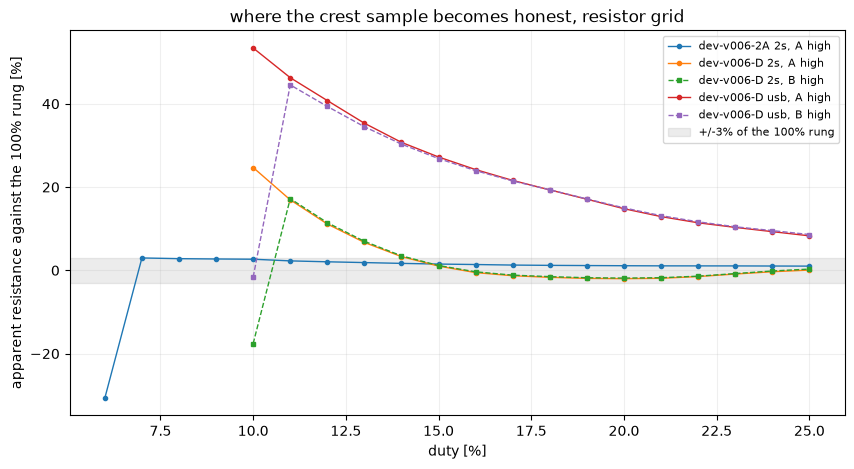

In [11]:
TOL_PCT = 3.0


def ladder_rungs(k, d):
    b, kv = d.board, K_VDD[k]
    out = []
    for cap in d.captures("ladder"):
        for rec in d.recordings("ladder", cap):
            df = frame(rec)
            base = df[df["seg"] == 0]
            base = base.iloc[len(base) // 2:]
            bias = base["current_raw"].median()
            for seg, g in df[df["seg"] > 0].groupby("seg"):
                g = settled(g)
                if len(g) < 20:
                    continue
                a, bb = g["vmotor_a"].mean(), g["vmotor_b"].mean()
                if ROUTE[k] == "ab":
                    v = abs(b.diff_v(a, bb)) * kv
                elif a > bb:
                    v = b.term_v(a, bb) * kv
                else:
                    continue
                i = abs(b.amps(g["current_raw"].mean(), bias)) * kv
                out.append({"dataset": k, "capture": cap, "seg": seg,
                            "duty_pct": abs(round(g["cmd_duty_q15"].iloc[0] * 100.0 / Q15)),
                            "dir": "A high" if a > bb else "B high",
                            "current_A": i, "V": v, "R_app_ohm": v / i,
                            "rail_V": b.vsys_v(g["vbus_raw"].mean()) * kv})
    return out


RUNGS = pd.DataFrame(sum((ladder_rungs(k, d) for k, d in GDS.items()), []))
LAD = (RUNGS.groupby(["dataset", "dir", "duty_pct"])
       .agg(rungs=("R_app_ohm", "size"), current_A=("current_A", "mean"), V=("V", "mean"),
            R_app_ohm=("R_app_ohm", "mean"), rail_V=("rail_V", "mean")).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for (k, direction), s in LAD.groupby(["dataset", "dir"]):
    s = s.set_index("duty_pct").sort_index()
    if 100 not in s.index:
        continue
    ref = s.loc[100, "R_app_ohm"]
    s = s[s.index < 100]
    ax.plot(s.index, (s["R_app_ohm"] / ref - 1) * 100, "-o" if direction == "A high" else "--s",
            ms=3, lw=1, label=f"{LABEL[k]}, {direction}")
    floor = None
    for duty in sorted(s.index, reverse=True):
        if abs(s.loc[duty, "R_app_ohm"] / ref - 1) * 100 > TOL_PCT:
            break
        floor = duty
    note = ""
    if floor is None:
        # No rung inside the band: a line over the top five rungs says where it would cross.
        # That crossing sits outside the measured range, so it is an extrapolation.
        top = s[s.index >= s.index.max() - 5]
        kk = np.polyfit(top.index.astype(float), top["R_app_ohm"], 1)
        note = f"no rung inside {TOL_PCT:.0f}%, a line over the top rungs crosses at {(ref * (1 + TOL_PCT / 100) - kk[1]) / kk[0]:.0f}% (extrapolated)"
    else:
        note = f"honest to {TOL_PCT:.0f}% from {floor:.0f}% duty"
    CARD[k][f"crest honest from, {direction} [% duty]"] = floor if floor is not None else np.nan
    CARD[k][f"100% rung R_app, {direction} [ohm]"] = ref
    print(f"{LABEL[k]:<20} {direction:<7} 100% rung {ref:.4f} ohm, lowest rung {s.index.min()}% "
          f"{(s['R_app_ohm'].iloc[0] / ref - 1) * 100:+.1f}% | {note}")
ax.axhspan(-TOL_PCT, TOL_PCT, color="grey", alpha=0.15, label=f"+/-{TOL_PCT:.0f}% of the 100% rung")
ax.set_xlabel("duty [%]")
ax.set_ylabel("apparent resistance against the 100% rung [%]")
ax.set_title("where the crest sample becomes honest, resistor grid")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** each rung's apparent resistance as a percentage of the same
board's 100% rung, per direction. The grey band is the 3% tolerance. A board whose crest
sample is honest at low duty stays inside the band further to the left.

### 5.1 Current against the load

The 100% rung is DC, so its terminal reading over the load's meter ohms is a current too, one
that needs no meter during the drive. The load is whatever the dataset measured where the
board sees it (`[load]` in its `dataset.toml`), and the grid's own header value when it says
nothing. On board D that is the 3.7 ohm at the grid header, which leaves the 0.02 ohm of
leads between the header and the taps in the reading, about +0.5% on the current error.

The route grades the current chain against the terminal chain and the meter's ohms at once,
VDD cancels out of it. On a tap-A board the forward reading also carries the low side in
series with the load, so the route takes off the A-side low path the reverse 100% rungs
measure. That assumes the B side matches it, which only a two-tap dataset can check. The
bracket is the meter's last digit on the load plus its class.

In [12]:
rows = []
for k, d in GDS.items():
    b, kv = d.board, K_VDD[k]
    for cap in d.captures("ladder"):
        for rec in [r for r in d.recordings("ladder", cap) if r.name == "top"]:
            df = frame(rec)
            base = df[df["seg"] == 0]
            bias = base["current_raw"].iloc[len(base) // 2:].median()
            for seg, g in df[df["seg"] > 0].groupby("seg"):
                g = settled(g)
                a, bb = g["vmotor_a"].mean(), g["vmotor_b"].mean()
                if ROUTE[k] == "ab":
                    v_load, v_low = abs(b.diff_v(a, bb)) * kv, np.nan
                elif a > bb:
                    v_load, v_low = b.term_v(a, bb) * kv, np.nan    # carries the B-side low path
                else:
                    v_load, v_low = np.nan, b.term_v(a, bb) * kv    # tap A is the low side
                rows.append({"dataset": k, "I_chip_A": abs(b.amps(g["current_raw"].mean(), bias)) * kv,
                             "V_load_V": v_load, "low_side_V": v_low,
                             "rail_rest_V": b.vsys_v(base["vbus_raw"].mean()) * kv,
                             "rail_V": b.vsys_v(g["vbus_raw"].mean()) * kv})
TOP = pd.DataFrame(rows)

for k, d in GDS.items():
    t, load = TOP[TOP["dataset"] == k], d.load
    r_app = (t["V_load_V"] / t["I_chip_A"]).mean()
    r_low = (t["low_side_V"] / t["I_chip_A"]).mean()
    # I_chip / (V / R_load) = R_load / (V / I_chip), with the low side the tap-A route reads in
    # series with the load taken off first.
    r_seen = r_app - (r_low if np.isfinite(r_low) else 0.0)
    bracket = np.hypot((load.hi - load.lo) / 2 / load.value * 100, METER_CLASS_PCT)
    c = CARD[k]
    c["load by meter [ohm]"] = load.value
    c["100% rung, chip V over chip I [ohm]"] = r_app
    c["A-side low path, reverse 100% rungs [ohm]"] = r_low
    c["current vs load route [%]"] = (load.value / r_seen - 1) * 100
    c["current vs load route, bracket [%]"] = bracket
    c["rail at rest, 100% captures [V]"] = t["rail_rest_V"].mean()
    c["rail at the 100% rung [V]"] = t["rail_V"].mean()
    c["source impedance, 100% rung [ohm]"] = ((t["rail_rest_V"] - t["rail_V"]) / t["I_chip_A"]).mean()
    print(f"{LABEL[k]:<20} load {load}")
    print(f"{'':<20} 100% rungs {t['I_chip_A'].mean():.3f} A, V/I {r_app:.4f} ohm"
          + (f", A-side low path {r_low:.4f} ohm, load seen {r_seen:.4f} ohm" if np.isfinite(r_low) else "")
          + f" -> current {(load.value / r_seen - 1) * 100:+.2f}% +/- {bracket:.2f}%"
          + (f" ({(load.value / r_app - 1) * 100:+.2f}% with the low side left in)" if np.isfinite(r_low) else ""))

dev-v006-D 2s        load 3.7 Ohm [3.6, 3.8] (DMM 200 ohm range at the grid header pins, probe offset 0.2 removed) - cold; 10.7 W laps heat it, tempco unmeasured
                     100% rungs 1.723 A, V/I 3.6237 ohm -> current +2.11% +/- 2.75%
dev-v006-D usb       load 3.7 Ohm [3.6, 3.8] (DMM 200 ohm range at the grid header pins, probe offset 0.2 removed) - cold; 10.7 W laps heat it, tempco unmeasured
                     100% rungs 1.126 A, V/I 3.6788 ohm -> current +0.58% +/- 2.75%
dev-v006-2A 2s       load 4.4 Ohm [4.3, 4.5] (J4 board terminals: DMM 200 ohm range at the J4 board terminals with the grid plugged, probe offset removed) - the grid is 3.7 ohm at its own header; its cable and contacts add about 0.7 ohm
                     100% rungs 1.622 A, V/I 4.4079 ohm, A-side low path 0.2178 ohm, load seen 4.1901 ohm -> current +5.01% +/- 2.33% (-0.18% with the low side left in)


## 6. The shunt inside one PWM period

The bursts free-run the ADC on the shunt alone at 26 ADC clocks a sample, 1.0833 us at
24 MHz, which is about 46 samples a period. Folding a burst on the period shows the current
inside the ON window, which the crest sample can only ever see one slice of. The longest ON
window in the set shows the whole approach, and the slot where it stays inside 1% of its
plateau says from which duty a crest sample centred in the window clears it.

dev-v006-D 2s        40% burst: plateau 1.710 A, inside 1% from slot 4 (4.3 us), a centred crest clears it from 17% duty; first slots 1.031 1.445 1.692 1.749 1.726 1.704
dev-v006-D usb       40% burst: plateau 1.122 A, inside 1% from slot 8 (8.7 us), a centred crest clears it from 35% duty; first slots 0.558 0.755 0.879 0.966 1.027 1.065
dev-v006-2A 2s       40% burst: plateau 1.601 A, inside 1% from slot 3 (3.2 us), a centred crest clears it from 13% duty; first slots 1.384 1.565 1.582 1.592 1.594 1.595


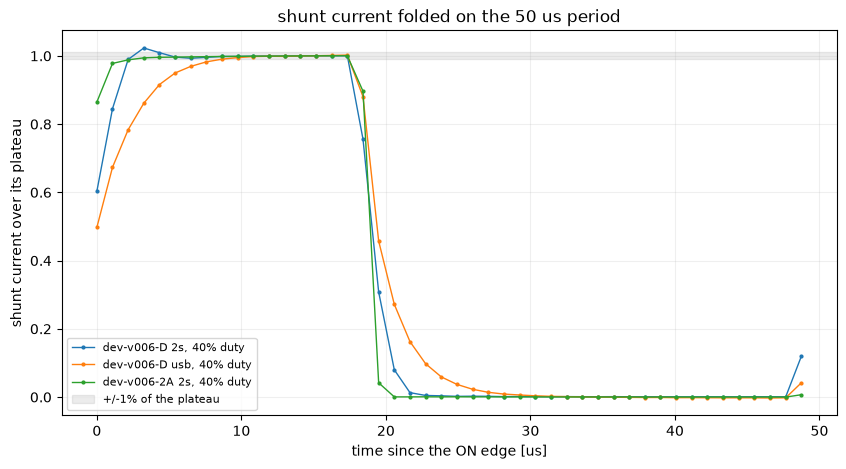

In [13]:
BURST_TS_US = 26 / 24.0
SETTLE_TOL = 0.01


def fold_burst(path, b, kv):
    # Average one burst over its PWM periods, aligned on the ON edge (median phase of the
    # biggest positive jumps, so one noisy period cannot shift the fold).
    raw = pd.read_csv(path)
    meta = raw.iloc[0]
    counts = raw["raw"].to_numpy(float)
    if int(meta["frame_len"]) != 1:
        counts = counts[::int(meta["frame_len"])]
    amps = b.amps(counts, float(meta["bias"])) * kv
    slots_f = 1e6 / b.tick_hz / BURST_TS_US
    edges = np.where(np.diff(amps) > 0.25 * (amps.max() - amps.min()))[0]
    phase = np.median(edges % slots_f)
    slots, nper = int(round(slots_f)), int(len(amps) // slots_f) - 1
    prof = np.full((nper, slots), np.nan)
    for p in range(nper):
        s = int(round(phase + p * slots_f)) + 1
        chunk = amps[s:s + slots]
        prof[p, :len(chunk)] = chunk
    return np.nanmean(prof, axis=0), slots_f


FOLDS = {}
for k, d in GDS.items():
    files = sorted((d.path / "burst").glob("c0-d*-*.csv"))
    if not files:
        print(f"{LABEL[k]}: no shunt bursts")
        continue
    duties = sorted({int(f.stem.split("-")[1][1:]) for f in files})
    for duty in duties:
        reps = [fold_burst(f, d.board, K_VDD[k]) for f in files if f.stem.split("-")[1] == f"d{duty}"]
        FOLDS[(k, duty)] = (np.nanmean([r[0] for r in reps], axis=0), reps[0][1])
    duty = duties[-1]
    prof, slots_f = FOLDS[(k, duty)]
    on = int(round(duty / 100 * slots_f))
    plateau = np.nanmean(prof[on - 6:on - 2])
    inside = np.abs(prof[:on - 2] - plateau) <= SETTLE_TOL * plateau
    first = len(inside)
    while first > 0 and inside[first - 1]:
        first -= 1
    c = CARD[k]
    c["burst plateau [A]"] = plateau
    c["shunt settled to 1% [us after the ON edge]"] = first * BURST_TS_US
    c["centred crest clears it from [% duty]"] = first * 2 / slots_f * 100
    print(f"{LABEL[k]:<20} {duty}% burst: plateau {plateau:.3f} A, inside 1% from slot {first} "
          f"({first * BURST_TS_US:.1f} us), a centred crest clears it from {first * 2 / slots_f * 100:.0f}% duty; "
          f"first slots " + " ".join(f"{x:.3f}" for x in prof[:6]))

fig, ax = plt.subplots(figsize=(10, 5))
for k in GDS:
    keys = [kd for kd in FOLDS if kd[0] == k]
    if not keys:
        continue
    kd = max(keys, key=lambda x: x[1])
    prof, _ = FOLDS[kd]
    ax.plot(np.arange(len(prof)) * BURST_TS_US, prof / CARD[k]["burst plateau [A]"], "-o", ms=2, lw=1,
            label=f"{LABEL[k]}, {kd[1]}% duty")
ax.axhspan(1 - SETTLE_TOL, 1 + SETTLE_TOL, color="grey", alpha=0.15, label="+/-1% of the plateau")
ax.set_xlabel("time since the ON edge [us]")
ax.set_ylabel("shunt current over its plateau")
ax.set_title("shunt current folded on the 50 us period")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** the shunt current inside one PWM period, as a fraction of its own
plateau, for the longest ON window each dataset has. The sooner a curve enters the grey band
and stays, the lower the duty at which a single crest sample reads the real current.

## 7. Board against board

One row per figure, one column per dataset, plus the figure each board's registry entry
carries and where it came from. A blank cell is a measurement that dataset does not have.

In [14]:
REGISTRY = {
    "dev-v006-D": {
        "VDD by meter [V]": "vdd_measured",
        "VB rest, tap A [counts]": "vb_bias_measured",
        "rest current sd [counts]": "opa_noise_floor_measured",
        "terminal vs meter, worst vs midpoint [%]": "terminal_chain_measured",
        "current vs meter, mean [%]": "current_chain_scale_measured",
        "crest honest from, A high [% duty]": "crest_floor_measured",
    },
    "dev-v006-2A": {
        "rest current sd [counts]": "rest_current_noise_measured",
        "current vs meter, mean [%]": "current_chain_scale_measured",
        "crest honest from, A high [% duty]": "crest_floor_measured",
    },
}
table = pd.DataFrame({LABEL[k]: CARD[k] for k in GDS})
for key, rows in REGISTRY.items():
    reg = oscnb.boards.BOARDS[key].measured
    table[f"{key} registry"] = [
        (f"{reg[rows[q]].value:g} [{reg[rows[q]].lo:g}, {reg[rows[q]].hi:g}] "
         f"({reg[rows[q]].source})") if q in rows else "" for q in table.index]
pd.set_option("display.max_colwidth", 70)
table.map(lambda v: round(v, 3) if isinstance(v, float) else v)

,dev-v006-D 2s,dev-v006-D usb,dev-v006-2A 2s,dev-v006-D registry,dev-v006-2A registry
terminal route,taps A and B,taps A and B,"tap A, tap B reads VB",,
VDD by meter [V],3.28,3.28,NaN,"3.28 [3.27, 3.29] (nb10 sec 2, DMM at the 3V3 test point, grid ses...",
"VB rest, tap A [counts]",779.168,779.059,769.78,"781 [775, 783] (Hi-Z rest baseline, 2S grid + stepcoast)",
"VB rest, tap B [counts]",783.146,783.023,771.034,,
VB nominal [counts],779.401,779.401,772.83,,
"VB rest, tap A [mV]",623.943,623.856,620.184,,
VB by meter [mV],NaN,NaN,NaN,,
rest current sd [counts],1.697,1.902,1.275,"2.2 [2, 2.4] (bringup isns-diff run29)","1.28 [1.22, 1.33] (nb10 sec 3, grid 2S ladder rest baselines)"
rest current sd [mA],1.51,1.692,1.151,,
rest tap A sd [mV at the terminal],2.009,1.802,3.458,,


Board D's column agrees with its registry entry everywhere they overlap. VDD is 3.28 V. The
terminal chain is within 0.44% of the meter's band on all five metered laps, 0.67% from the
worst midpoint, and three of the five sit inside the band. The crest current is honest from
15% duty in both directions on 2S and from no rung of the USB ladder. The 40% burst settles
inside 1% at slot 4 on 2S, 4.3 us, and slot 8 on USB. The current chain lands at +1.13%
against the registry's +1.2%, which took the session log's 0.04 V lead drop where section 4.2
takes the measured 0.031 V. The load route of section 5.1 gives +2.1% on 2S and +0.6% on USB, inside the same 2.7%
bracket, which is a fair sanity check of the route itself.

Rev 2A, against those numbers:

- **Rest.** Both taps sit on the bias node within 3 counts of the 773 nominal. The rest
  current is quieter, 1.3 counts against 1.7, and the frame-position spread is 0.85 counts
  against 0.59, still under the noise. Tap A's rest noise is 3.5 mV at the terminal against
  2.0, which is the coarser 4 mV per count of the 6k4/1k6 divider, about 0.86 counts either
  way.
- **Crest floor.** Honest to 3% from 7% duty, against 15%, though the 7% rung sits right on
  the edge at +3.0% and the whole ladder runs 1 to 3% above the 100% rung, flat rather than
  climbing. Below 7% it is tap A that is early,
  not the current. The ladder's 5% rung reads 97% of the 25% rung's current while tap A has
  not left the low side yet, which is the vmA sample closing 79 ticks after the crest, 6.6% duty
  of ON half-window.
- **Shunt edge.** Inside 1% from slot 3, 3.2 us after the ON edge, so a centred crest clears it
  from 13% duty, against slot 4, 4.3 us and 17%. The first slot already carries 87% of the
  plateau against board D's 60%.
- **Rail.** 7.73 V at rest and 7.40 V at the 100% rung, 0.21 ohm of source, the same pack
  behaviour board D showed.
- **Current.** No DC laps in this dataset, so no meter route here. The load route reads
  4.408 ohm of chip volts per chip amp at 100% against 4.4 ohm on the meter at J4. Taking off
  the 0.218 ohm A-side low path the reverse rungs measure leaves 4.190 ohm, which would put the
  chip current 5.0% high, bracket 2.3%. A lap with the meter across Rs1 settles it. The meter
  read 93 to 94 mV across Rs1 during a 4.2 s 100% grid lap, against 93.3 to 95.1 mV from the
  chip's current over the nominal 60 mOhm, median 94.0. The shunt cancels out of that route, so
  the amplifier and the ADC sit within about 1% of nominal, +0.5% with a -0.7 to +2.3% bracket.
  The 5% is the meter's ohms range at J4 reading the load low, the way a cheap meter read board
  D's grid low. The registry carries the Rs1 figure as `current_chain_scale_measured`.

Two registry rows are not reruns of anything here. The bias figure, 781 counts, came from the
servo campaigns' torque-off baselines rather than the grid. On the grid baseline the taps read
779 and 783 (section 3), inside its [775, 783] bracket, with the same four-count split between
them. The 2.2-count amplifier floor came
from a bringup bench run, and the grid baseline's 1.7 counts is the whole chain at rest with
the bridge off.

## 8. Drive window floors

The firmware reads a current or a terminal only when the drive window is at least
`i_window_min_ticks` or `v_window_min_ticks` wide, both 160 on the osc-dev-v006 build. The
window is `drive_ticks` either side of the counter crest, in 48 MHz timer ticks out of an ARR
of 1200, so 160 ticks is 13.3% duty. Every host tool plans against that floor, and below it the
current limit, calibration and ident are blind. This section derives the floor per board from
the scan geometry and the measured settle.

The crest scan starts on TRGO at the crest. The ADC adds a 2-clock trigger delay (datasheet
Table 3-23), then spends 26 clocks a slot at 24 MHz and holds each sample at the end of a
13.5-clock aperture. At two timer ticks a clock, slot $k$ closes its sample

$$t_k = 4 + 52\,k + 27 \text{ ticks after the crest:}\quad 31 \text{ for the shunt, } 83 \text{ for tap A, } 135 \text{ for tap B.}$$

Two things must hold at that instant. The bridge must still be on, so the sample sits inside
the window, and the signal must have settled since the bridge turned on, $h + t_k$ ticks after
the ON compare for a window of $h$. For the shunt the first is never the one that binds and
the floor is all settle. For the taps it is the other way round: their RC settles in well under
a microsecond, and the floor is where the sample still lands before the OFF edge.

### 8.1 The shunt from the ON compare

Section 6's fold quantizes time to one slot, 52 ticks. A burst samples every 52 ticks and the
period is 2400, so the sample phase walks through the period and repeats every 13 periods,
600 phases 4 ticks apart. Placing each sample at its own phase, from the timer count the burst
launched at, rebuilds the edge at 4-tick (83 ns) resolution, and each burst is aligned on its
own rising half-way point.

A burst does not see the timer. The ladders do: a rung of width $h$ samples the current
$h + 31$ ticks after the ON compare, so its reading against the 100% rung is the fold at
$h + 31 - \Delta$, where $\Delta$ is the time from the compare to the current's half-way point,
times a scale that carries the fold's own reference over to the 100% rung. One $\Delta$ and one
scale per dataset, fitted over every rung up to 25%, register the fold on the timer.

In [15]:
TRIG_TICKS = 4                  # 2 ADC clocks of trigger delay
CONV_TICKS = 25                 # 12.5 ADC clocks of conversion after the aperture
APERTURE_TICKS = 27             # 13.5 ADC clocks, every slot
PERIOD_TICKS = 2400


def sample_close(slot, aperture=APERTURE_TICKS):
    return TRIG_TICKS + slot * (aperture + CONV_TICKS) + aperture


SH_SHUNT = sample_close(0)


def drive_ticks(q15, b):
    # window.rs `drive_ticks`: the compare width the motor write programs.
    return (abs(int(q15)) * b.pwm_half_ticks + (1 << 14)) >> 15


def crossing(seg, level):
    above = seg.to_numpy() > level
    i = np.flatnonzero(above != above[0])[0]
    t0, t1 = seg.index[i - 1], seg.index[i]
    y0, y1 = seg.iloc[i - 1], seg.iloc[i]
    return t0 + (level - y0) / (y1 - y0) * (t1 - t0)


def fold_fine(path, b):
    raw = pd.read_csv(path)
    meta = raw.iloc[0]
    amps = b.amps(raw["raw"].to_numpy(float)[::int(meta["frame_len"])], float(meta["bias"]))
    step = CONV_TICKS + APERTURE_TICKS
    cnt = int(meta["start_cnt"])
    # Phase from the crest of the launch, negative while the counter still climbs (DIR = UP).
    phase = cnt - b.pwm_half_ticks if int(meta["start_dir"]) == 0 else b.pwm_half_ticks - cnt
    t = (phase + step * np.arange(len(amps)) + PERIOD_TICKS // 2) % PERIOD_TICKS - PERIOD_TICKS // 2
    p = pd.Series(amps).groupby(t).mean()
    h = drive_ticks(meta["step_q15"], b)
    half = (p[np.abs(p.index) > h + 200].median() + p[np.abs(p.index) < h / 2].median()) / 2
    rise = crossing(p[(p.index > -h - 200) & (p.index < 0)], half)
    fall = crossing(p[(p.index > 0) & (p.index < h + 200)], half)
    return pd.DataFrame({"tau": t - rise, "amps": amps}), 2 * h - (fall - rise)


def current_rungs(d):
    # Every settled rung's crest current, both drive signs, against the 100% rung of the same
    # sign. The taps play no part.
    b, rows = d.board, []
    for cap in d.captures("ladder"):
        for rec in d.recordings("ladder", cap):
            df = frame(rec)
            base = df[df["seg"] == 0]
            bias = base["current_raw"].iloc[len(base) // 2:].median()
            for seg, g in df[df["seg"] > 0].groupby("seg"):
                g = settled(g)
                if len(g) < 20:
                    continue
                q = g["duty_q15"].median()
                rows.append({"sign": "+" if q > 0 else "-", "ticks": drive_ticks(q, b),
                             "amps": abs(b.amps(g["current_raw"].mean(), bias))})
    r = pd.DataFrame(rows).groupby(["sign", "ticks"])["amps"].mean().reset_index()
    ref = r[r["ticks"] == b.pwm_half_ticks].set_index("sign")["amps"]
    r["vs_100"] = r["amps"] / r["sign"].map(ref)
    return r[r["ticks"] < b.pwm_half_ticks]


FINE, SHORT = {}, {}
for k, d in GDS.items():
    for f in sorted((d.path / "burst").glob("c0-d*-*.csv")):
        duty = int(f.stem.split("-")[1][1:])
        df, short = fold_fine(f, d.board)
        FINE.setdefault((k, duty), []).append(df)
        SHORT.setdefault(k, []).append(short)
for key, parts in FINE.items():
    df = pd.concat(parts)
    FINE[key] = df.groupby((df["tau"] / 4).round() * 4)["amps"].mean().rolling(3, center=True).mean()

LADI = {k: current_rungs(d) for k, d in GDS.items()}
OWN, REG = {}, {}
for k, d in GDS.items():
    duty = max(dd for kk, dd in FINE if kk == k)
    h = duty * d.board.pwm_half_ticks // 100
    p = FINE[(k, duty)]
    OWN[k] = p / p[(p.index >= 2 * h - 200) & (p.index <= 2 * h - 100)].mean()
    f = OWN[k].dropna()
    L = LADI[k][LADI[k]["ticks"] <= 300]
    fits = []
    for delta in range(-40, 160):
        y = np.interp(L["ticks"] + SH_SHUNT - delta, f.index, f.to_numpy())
        s = (y @ L["vs_100"]) / (y @ y)
        fits.append((np.sqrt(np.mean((L["vs_100"] - s * y) ** 2)), delta, s))
    rms, delta, s = min(fits)
    REG[k] = {"delta": delta, "scale": s}
    print(f"{LABEL[k]:<20} compare to half-way {delta} ticks ({delta / 48:.2f} us), fold over the "
          f"100% rung {(s - 1) * 100:+.2f}%, rms {rms * 100:.2f}% over {len(L)} rungs | pulse "
          f"{np.mean(SHORT[k]):.0f} ticks shorter than commanded at half height")

dev-v006-D 2s        compare to half-way 90 ticks (1.88 us), fold over the 100% rung +0.45%, rms 0.09% over 32 rungs | pulse 28 ticks shorter than commanded at half height
dev-v006-D usb       compare to half-way 92 ticks (1.92 us), fold over the 100% rung -0.97%, rms 0.18% over 32 rungs | pulse 10 ticks shorter than commanded at half height
dev-v006-2A 2s       compare to half-way 44 ticks (0.92 us), fold over the 100% rung +0.56%, rms 0.08% over 42 rungs | pulse 30 ticks shorter than commanded at half height


The fit holds every rung of the 2A ladder to 0.08% rms with one delay, so the fold and the
ladder tell one story. On rev 2A the current reaches half its step 44 ticks (0.92 us) after the
ON compare, and the pulse it draws is 30 ticks shorter than the commanded window at half height:
turning on and climbing to half takes 30 ticks longer than turning off and falling to half.
Section 8.4 dates the turn-off from the taps at about 9 ticks, so most of the 44 is the bridge
turning on. Board D's half-way point sits 90 ticks out and its pulse is short by about the same
28 ticks, so its amplifier is slow in both directions. The scale says the end of the longest burst window reads 0.56% above the 100% rung on 2A, a slow
tail that a 40% window has not finished; against a 1% tolerance it does not matter, against
0.5% it is the reference itself that is unsettled.

### 8.2 Floor against accuracy

For each tolerance: the settle time from the ON compare on the fold scaled to the 100% rung,
the window that puts the shunt sample there, the same window against the fold's own end
instead, and the floor read straight off the ladder rungs per drive sign. The ladder floor interpolates between the last rung outside the band and
the first one in it, and only counts a band the rungs never leave again. The last column is the
sign of the error just under the floor.

In [16]:
TOLS = [0.5, 1, 2, 3, 5, 10]


def fold_settle(p, tol):
    # First time after which the fold stays inside the band, up to the end of its window.
    p = p[(p.index >= 0) & (p.index <= 760)].dropna()
    out = np.flatnonzero(np.abs(p.to_numpy() - 1) > tol)
    if len(out) and out[-1] + 1 >= len(p):
        return np.nan
    return p.index[out[-1] + 1] if len(out) else p.index[0]


def ladder_floor(r, tol):
    r = r.sort_values("ticks")
    err = r["vs_100"].to_numpy() - 1
    out = np.flatnonzero(np.abs(err) > tol)
    if not len(out):
        return f"<= {r['ticks'].iloc[0]}", "low"
    i = out[-1]
    if i + 1 >= len(r):
        return f"> {r['ticks'].iloc[-1]}", "low" if err[i] < 0 else "high"
    t0, t1 = r["ticks"].iloc[i], r["ticks"].iloc[i + 1]
    e0, e1 = abs(err[i]), abs(err[i + 1])
    return f"{t0 + (e0 - tol) / (e0 - e1) * (t1 - t0):.0f}", "low" if err[i] < 0 else "high"


rows = []
for k, d in GDS.items():
    dc = OWN[k] * REG[k]["scale"]
    lowest = LADI[k]["ticks"].min()
    for tol in TOLS:
        tau = fold_settle(dc, tol / 100)
        settle = tau + REG[k]["delta"]
        floor = settle - SH_SHUNT
        lad = {sgn: ladder_floor(g, tol / 100) for sgn, g in LADI[k].groupby("sign")}
        own = fold_settle(OWN[k], tol / 100) + REG[k]["delta"] - SH_SHUNT
        rows.append({"dataset": LABEL[k], "tol [%]": tol, "settle [ticks]": settle,
                     "floor [ticks]": floor, "floor [% duty]": floor * 100 / d.board.pwm_half_ticks,
                     "vs own end [ticks]": own,
                     "ladder +": lad["+"][0], "ladder -": lad["-"][0],
                     "reads": "/".join(sorted({lad["+"][1], lad["-"][1]})),
                     "note": "fold only, under the lowest rung" if floor < lowest else ""})
FLOORS = pd.DataFrame(rows).set_index(["dataset", "tol [%]"])
FLOORS.round(1)

settle [ticks]  floor [ticks]  floor [% duty]  \
dataset        tol [%]                                                  
dev-v006-D 2s  0.5               774.0          743.0            61.9   
               1.0               322.0          291.0            24.2   
               2.0               306.0          275.0            22.9   
               3.0               198.0          167.0            13.9   
               5.0               190.0          159.0            13.2   
               10.0              174.0          143.0            11.9   
dev-v006-D usb 0.5                 NaN            NaN             NaN   
               1.0                 NaN            NaN             NaN   
               2.0               512.0          481.0            40.1   
               3.0               452.0          421.0            35.1   
               5.0               388.0          357.0            29.8   
               10.0              296.0          265.0            22.1   
dev-v006-2A 2s 0.5                 NaN            NaN             NaN   
               1.0               156.0          125.0            10.4   
               2.0               112.0           81.0             6.8   
               3.0                88.0           57.0             4.8   
               5.0                76.0           45.0             3.8   
               10.0               68.0           37.0             3.1   

                        vs own end [ticks] ladder + ladder - reads  \
dataset        tol [%]                                               
dev-v006-D 2s  0.5                   459.0    > 300    > 300  high   
               1.0                   283.0      291      289  high   
               2.0                   267.0      271      270  high   
               3.0                   171.0      166      166   low   
               5.0                   163.0      159      158   low   
               10.0                  147.0      143      142   low   
dev-v006-D usb 0.5                   565.0    > 300    > 300   low   
               1.0                   485.0    > 300    > 300   low   
               2.0                   425.0    > 300    > 300   low   
               3.0                   389.0    > 300    > 300   low   
               5.0                   325.0    > 300    > 300   low   
               10.0                  257.0      262      266   low   
dev-v006-2A 2s 0.5                   233.0      147      158   low   
               1.0                   153.0      119      123   low   
               2.0                   101.0       74       77   low   
               3.0                    65.0    <= 60    <= 60   low   
               5.0                    49.0    <= 60    <= 60   low   
               10.0                   37.0    <= 60    <= 60   low   

                                                    note  
dataset        tol [%]                                    
dev-v006-D 2s  0.5                                        
               1.0                                        
               2.0                                        
               3.0                                        
               5.0                                        
               10.0                                       
dev-v006-D usb 0.5                                        
               1.0                                        
               2.0                                        
               3.0                                        
               5.0                                        
               10.0                                       
dev-v006-2A 2s 0.5                                        
               1.0                                        
               2.0                                        
               3.0      fold only, under the lowest rung  
               5.0      fold only, under the lowest rung  
               10.0     fold only, under 

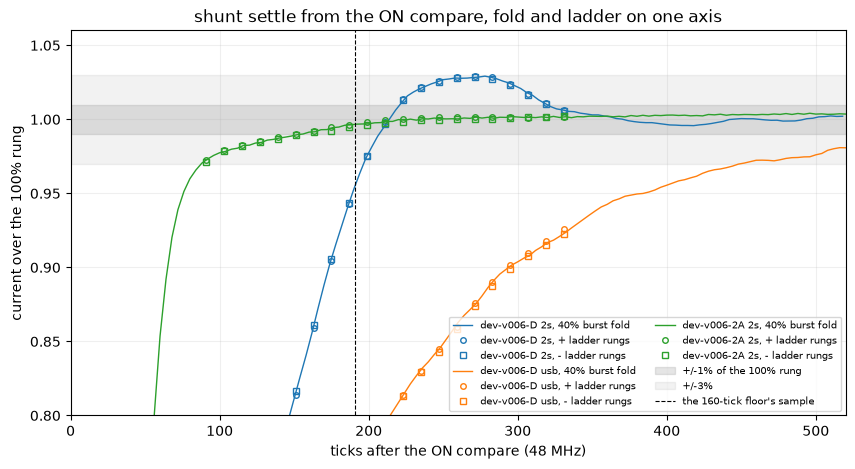

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, (k, d) in enumerate(GDS.items()):
    dc = OWN[k] * REG[k]["scale"]
    x = dc.index + REG[k]["delta"]
    keep = (x >= 0) & (x <= 520)
    line, = ax.plot(x[keep], dc[keep], lw=1, label=f"{LABEL[k]}, 40% burst fold")
    for sgn, mk in (("+", "o"), ("-", "s")):
        r = LADI[k][LADI[k]["sign"] == sgn]
        ax.plot(r["ticks"] + SH_SHUNT, r["vs_100"], mk, ms=4, mfc="none", color=line.get_color(),
                label=f"{LABEL[k]}, {sgn} ladder rungs")
ax.axhspan(0.99, 1.01, color="grey", alpha=0.2, label="+/-1% of the 100% rung")
ax.axhspan(0.97, 1.03, color="grey", alpha=0.1, label="+/-3%")
ax.axvline(160 + SH_SHUNT, color="k", lw=0.8, ls="--", label="the 160-tick floor's sample")
ax.set_xlim(0, 520)
ax.set_ylim(0.8, 1.06)
ax.set_xlabel("ticks after the ON compare (48 MHz)")
ax.set_ylabel("current over the 100% rung")
ax.set_title("shunt settle from the ON compare, fold and ladder on one axis")
ax.grid(alpha=0.2)
ax.legend(fontsize=7, ncol=2)
plt.show()

**What you are looking at:** the longest burst fold of each dataset, scaled to its 100% rung and
moved onto the timer by the fitted delay, with every ladder rung plotted where its crest sample
closes, $h + 31$ ticks after the ON compare. A floor of $h$ ticks is honest to a tolerance when
everything right of $h + 31$ stays inside that band. The dashed line is where the 160-tick floor
samples.

Rev 2A approaches its plateau from below and never crosses it, so under any floor its current
reads low, and a current limit there sees less than flows. It is inside 3% from the lowest rung
the ladder has, 60 ticks, and inside 1% from 119 ticks on positive rungs and 123 on negative,
with the fold at 125. At 160 it reads 0.3 to 0.5% low. Board D is a different shape: it climbs
for longer, then overshoots by up to 2.9% at 240 ticks before it settles, so it reads low under
about 180 ticks and high from there to about 300. The 160 floor was a 5% floor on board D, and
on USB its 25% rung still reads 7% low.

### 8.3 Small currents

Every burst here drives the same grid from the same pack, so every fold is the same 1.6 A step
whatever its duty. Low duty on a motor is a different thing, a small winding current and so a
small step at the ON edge. Whether the settle carries over depends on what limits the edge: a
slew-limited amplifier takes longer for a bigger step and less for a smaller one, a
bandwidth-limited one takes the same fraction of its step in the same time.

In [18]:
for k, d in GDS.items():
    b = d.board
    duties = sorted(dd for kk, dd in FINE if kk == k)
    shape = {}
    for duty in duties:
        p = FINE[(k, duty)]
        ref = p[(p.index >= 130) & (p.index <= 170)].mean()
        shape[f"{duty}%, {ref:.2f} A"] = (p / ref).reindex([-8, 0, 8, 16, 24, 48, 96]).round(3)
    print(LABEL[k], "- each fold over its own reading 130-170 ticks after the half-way point")
    print(pd.DataFrame(shape).T.to_string())
    p = FINE[(k, duties[-1])]
    seg = (p / p[(p.index >= 130) & (p.index <= 170)].mean())[(p.index >= 0) & (p.index <= 24)]
    tau = -1 / np.polyfit(seg.index, np.log(1 - seg), 1)[0]
    slope = (p * b.shunt_ohm * b.amp_gain).diff().max() / 4 * 48     # V/us at the amplifier output
    print(f"  half-way to 24 ticks closes with a time constant of {tau:.1f} ticks ({tau / 48 * 1e3:.0f} ns); "
          f"steepest {slope:.1f} V/us at the amplifier output\n")

dev-v006-D 2s - each fold over its own reading 130-170 ticks after the half-way point
tau            -8      0      8      16     24     48     96
10%, 1.75 A  0.309  0.395  0.461  0.512  0.556  0.684  0.885
15%, 1.76 A  0.421  0.480  0.525  0.569  0.613  0.734  0.915
20%, 1.76 A  0.427  0.484  0.530  0.574  0.618  0.737  0.916
25%, 1.76 A  0.437  0.491  0.536  0.577  0.621  0.740  0.919
40%, 1.75 A  0.442  0.495  0.539  0.582  0.626  0.745  0.921
  half-way to 24 ticks closes with a time constant of 80.1 ticks (1668 ns); steepest 1.0 V/us at the amplifier output

dev-v006-D usb - each fold over its own reading 130-170 ticks after the half-way point
tau            -8      0      8      16     24     48     96
10%, 0.93 A  0.305  0.421  0.512  0.576  0.625  0.732  0.874
15%, 0.94 A  0.376  0.477  0.553  0.606  0.648  0.744  0.880
20%, 0.95 A  0.450  0.528  0.584  0.628  0.666  0.758  0.890
25%, 0.95 A  0.480  0.549  0.600  0.640  0.674  0.764  0.892
40%, 0.96 A  0.528  0.581  0.623  0.6

Rev 2A's edge is the same at every duty, to within the alignment of the half-way point, and it
is a decaying exponential, not a ramp: from the half-way point it closes on the plateau with a
time constant of about 12 ticks (0.25 us). That is the amplifier's closed-loop bandwidth,
GBW 12 MHz at a noise gain of 14.9 makes about 0.8 MHz or 0.2 us, and the steepest part of the
edge runs at 2.8 V/us against the datasheet's 10 V/us slew. A bandwidth-limited edge settles
the same fraction of any step in the same time, so the fast part of the floor carries over to
small currents. What this data cannot say is whether the slow 3% tail behind the edge, the part
that sets the 1% floor, scales with the step too. The capture that says it is the same 2A shunt
burst set at 10, 15 and 25% duty on a load about ten times the grid's, roughly 40 ohm for a
0.18 A step, and one about three times it, around 13 ohm for 0.55 A. If those folds lie on the
4.4 ohm fold, the floor holds at any current.

### 8.4 Terminals and shorter apertures

The terminal floor is the tap B sample's position: it closes 135 ticks after the crest, and a
rung that ends just before it catches the tap partway down its RC, which dates the fall.

In [19]:
TAP_CAP_PF = {"dev-v006-D": 150, "dev-v006-2A": 100}     # Cv on each board, from its notes
rows = []
for k, d in GDS.items():
    if d.supply != "2s":
        continue
    b = d.board
    r_th = b.vmotor_div_top * b.vmotor_div_bot / (b.vmotor_div_top + b.vmotor_div_bot)
    rc = r_th * TAP_CAP_PF[b.key] * 1e-12 * 48e6
    taps = [("A", "vmotor_a", "+", 1)] + ([("B", "vmotor_b", "-", 2)] if ROUTE[k] == "ab" else [])
    for name, col, sgn, slot in taps:
        lv = []
        for cap in d.captures("ladder"):
            for rec in d.recordings("ladder", cap):
                df = frame(rec)
                vb = df[df["seg"] == 0][col].median()
                for seg, g in df[df["seg"] > 0].groupby("seg"):
                    g = settled(g)
                    q = g["duty_q15"].median()
                    if len(g) < 20 or (q > 0) != (sgn == "+"):
                        continue
                    bias = g["vmotor_b"].mean() if ROUTE[k] == "a" else vb
                    lv.append({"ticks": drive_ticks(q, b), "v": b.term_v(g[col].mean(), bias)})
        lv = pd.DataFrame(lv).groupby("ticks")["v"].mean()
        full = lv[(lv.index > lv.index.min() + 24) & (lv.index <= 300)].median()
        part = lv[(lv / full > 0.1) & (lv / full < 0.9)]
        for h, v in part.items():
            # f = exp(-late / RC): how long after the fall began the sample closed
            cut = h + rc * np.log(full / v)
            rows.append({"dataset": LABEL[k], "tap": name, "rung [ticks]": h, "reads [% of high]": v / full * 100,
                         "RC [ticks]": rc, "stops seeing the window [ticks]": cut,
                         "sample closes [ticks]": sample_close(slot),
                         "turn-off lag [ticks]": sample_close(slot) - cut})
TAPS = pd.DataFrame(rows)
print(TAPS.round(1).to_string(index=False))
LAG = TAPS["turn-off lag [ticks]"].mean()
print(f"\ntap B on either board stops seeing the window about {sample_close(2) - LAG:.0f} ticks after the crest\n")

# The same geometry with a shorter aperture on slots 0-2. A tap's 100 pF holds the sample cap's
# 4 pF (datasheet Table 3-23) to a 3.8% kick at connection, which the tap recovers through its
# Thevenin resistance; the step is tap B after tap A with A driven and B low.
d2a = next(d for d in GDS.values() if d.board.key == "dev-v006-2A")
b = d2a.board


def tap_raw(d, col, sgn, ticks):
    vals = []
    for cap in d.captures("ladder"):
        for rec in d.recordings("ladder", cap):
            for seg, g in frame(rec).groupby("seg"):
                g = settled(g)
                q = g["duty_q15"].median() if len(g) else 0
                if seg > 0 and len(g) >= 20 and drive_ticks(q, d.board) == ticks and (q > 0) == (sgn == "+"):
                    vals.append(g[col].mean())
    return np.mean(vals)


# tap A driven high less tap A driven low, both at the 25% rungs
step = tap_raw(d2a, "vmotor_a", "+", 300) - tap_raw(d2a, "vmotor_a", "-", 300)
print(f"tap B after tap A at full swing: a {step:.0f}-count step")
r_th = b.vmotor_div_top * b.vmotor_div_bot / (b.vmotor_div_top + b.vmotor_div_bot)
c_adc, c_tap = 4e-12, 100e-12
rows = []
for cycles in (3.5, 7.5, 13.5):
    ap = int(cycles * 2)
    t_ap = cycles / 24e6
    rows.append({"aperture [ADC clocks]": cycles, "rate [Msps]": 24 / (cycles + 12.5),
                 "rated down to VDD [V]": 2.4 if 24 / (cycles + 12.5) <= 1 else 4.5,
                 "shunt closes [ticks]": sample_close(0, ap),
                 "current floor moves [ticks]": APERTURE_TICKS - ap,
                 "tap B closes [ticks]": sample_close(2, ap),
                 "tap B floor [ticks]": sample_close(2, ap) - LAG,
                 "tap residual after the aperture [counts]":
                     step * c_adc / (c_adc + c_tap) * np.exp(-t_ap / (r_th * (c_adc + c_tap)))})
pd.DataFrame(rows).set_index("aperture [ADC clocks]").round(2)

       dataset tap  rung [ticks]  reads [% of high]  RC [ticks]  stops seeing the window [ticks]  sample closes [ticks]  turn-off lag [ticks]
 dev-v006-D 2s   B           120               68.4        16.0                            126.1                    135                   8.9
dev-v006-2A 2s   A            72               67.0         6.1                             74.5                     83                   8.5

tap B on either board stops seeing the window about 126 ticks after the crest



tap B after tap A at full swing: a 1733-count step


,rate [Msps],rated down to VDD [V],shunt closes [ticks],current floor moves [ticks],tap B closes [ticks],tap B floor [ticks],tap residual after the aperture [counts]
aperture [ADC clocks],,,,,,,
3.5,1.50,4.5,11,20,75,66.26,22.29
7.5,1.20,4.5,19,12,99,90.26,6.37
13.5,0.92,2.4,31,0,135,126.26,0.97


Two partial rungs, one per board and one per tap, put the moment the terminal starts to fall
8.5 to 9 ticks after the compare, so tap B is good from about 126 ticks and tap A from about
74. `v_window_min_ticks` at 160 keeps 34 ticks over tap B and stays.

Shorter apertures do not get under it. With `ADC_LP` set, which the build does, a channel
samples for 3.5, 7.5, 13.5 or more clocks (RM sec 9.3.4), and the two shorter ones run a slot
at 1.5 and 1.2 Msps, which datasheet Table 3-23 rates only at VDD >= 4.5 V. On a 3.3 V board
they are out. Were they in, tap B would gain 36 or 60 ticks and the shunt would lose 12 or 20,
because its sample moves closer to the ON edge. Neither would charge a tap's 100 pF back to
within 1/2 LSB after a 1733-count step from the slot before it, leaving about 6 and 22 counts;
13.5 clocks leaves about 1, so even it is not at 1/2 LSB on that one step. That residual assumes the sample cap starts each aperture from the
previous conversion, which the datasheet does not say. The amplifier output has no cap of its
own (Co1 DNP) and a 0.2 to 0.25 us time constant, longer than a 3.5-clock aperture's 0.15 us.

### 8.5 The floors for rev 2A

Superseded. The floors that ship are notebook 16's: 64 ticks for the current, where a settle gain
per 8-tick band makes up the 3% under-read this section allows for, and 93 ticks for the terminals,
with tap B sampled before the crest and the taps swapped in reverse. What follows is the 1% floor
without a settle gain and the terminal floor with tap B in its old slot, kept because the
derivation is the method notebook 16 builds on.


**`i_window_min_ticks` = 132 (11.0% duty).** The 1% crossing is 119 ticks on positive rungs,
123 on negative and 125 on the fold, and 132 is a measured rung in both directions, reading
0.8% low on each. Near the floor the error moves about 0.02% a tick, so the 9 to 13 ticks of
margin (0.2 to 0.27 us) absorb that much drift in the bridge's turn-on for 0.2% more error.
Under the floor the reading only ever goes low. If a 3% under-read at the floor is acceptable,
64 ticks (5.3%) holds it on the lowest rung measured and halves the blind band again.

**`v_window_min_ticks` = 160**, unchanged, per section 8.4.

One coupling moves with the current floor: `trough_is_brake` in `window.rs` feeds the bias
tracker only with six floors of brake, 960 ticks at a 160 floor, which is the 20% duty ceiling
its comment measured. At 132 the same rule feeds it up to 34% duty, where that comment has the
trough 7 counts high. The brake minimum needs its own number before the floor moves.

**What verifies it.** A rev-2A ladder through the floor: rungs every 4 ticks from 40 to 200 in
both directions with 100% rungs for the reference, on 2S and on USB, first on the grid and then
on the MG90 under its saved current limit, where the step at the ON edge is the winding
current. It passes when every rung from 132 ticks up reads inside 1% of its 100% rung, in both
directions, on both supplies.

## 9. Current sense on the final amplifier network

After the grid sessions above, board #1's current amplifier got reworked a few times. It now
runs Rg 430, Ci1 47 pF, no compensation caps (Cc out), and two 1.5k pull-ups from 3V3 to the
op-amp's two inputs. The pull-ups lift the inputs' common mode, which is the voltage both
inputs sit at together, from about 0.07 V to about 0.75 V. This section asks whether the
current reading is honest on that network, on a stalled MG90 and on a plain resistor, and
whether the settle gain the firmware ships (`i_settle_gain`, a per-window correction on top of
the 64-tick current floor) still fits it.

Here is the quick version, each line backed by a cell below:

- On a stalled MG90 the crest reads above a series meter by about 3.7 mA per terminal volt,
  in windows of 180 ticks and up. With one motor lead off it is about 1 mA or less, and at
  100% duty the crest and the meter agree to half a percent, so the extra needs the motor. This
  was measured on the old network only.
- On a 15.3 ohm resistor the raw chain reads within 0.6% from a 48-tick window, the same in four
  runs to 0.2%. Positive duty only.
- On the motor the 2% floor of the final network is 54 ticks at 4.5 V and 58 at 8.4 V in the
  worst of three repeats, both under the shipped 64.
- The shipped settle gain over-reads the resistor by 3.6 to 4.1% at the floor. A flat unity
  table reads it within 0.6% from 48 ticks.

### 9.1 The question

Five things to settle, in the order the evidence comes in:

1. The crest current reads above a series ammeter on the stalled motor. Is that extra real
   motor current that flows only while the bridge is ON, or something the board makes?
2. Did the input pull-ups cut the error right after turn-on?
3. Are Ci1 (0, 22 or 47 pF across the inputs) and the gain resistor Rg (430 or 820) levers on
   that error?
4. Does the chain read a resistor within 2% from a 48-tick window, repeatably, and is what is
   left on the motor the motor's own turn-on charge?
5. Is the shipped `i_settle_gain` still right on the new network?

### 9.2 The procedure

All of it is existing data, no new bench work. Three kinds of capture, all on rev 2A board #1
fed by the DPS-150, all at a fixed OpenLoop duty:

| capture | load and network | what varied between runs |
|---|---|---|
| holds against a series meter (`gap/`, `open-load/`) | stalled MG90 at a stop, B41T+ on DC amps in series with one motor lead, on the old (caps-in) network only | rail, duty, stop, session |
| steady-state bursts (`floor/`) | stalled MG90, 4.5 V at D 6/8/10%, 8.4 V at D 6/8/10/15%, low and high stop, 10 bursts per hold | network, one session each, and the final network in five sessions (cm1k5, rev430, m1 to m3, the last three after 26 minutes off and a fresh zero) |
| steady-state bursts on a resistor | 15.3 ohm of wirewound on J4, D 3.5 to 25% (w 42 to 300 ticks), final network, positive duty only | four runs, the last after a power cycle and a 70 s gap |

A steady-state burst is taken with the burst duty equal to the hold duty, so no step happens
inside it and every PWM period in it is the same period. The bursts free-run the ADC at one
sample per 52 timer ticks and fold onto the 2400-tick period from the stamp in their first
row.

None of these captures has a `meta.json`, so there is no `sense` block for `check_meta` to
read. Each dataset's `dataset.toml` names the board and says why. The board entry supplies
only timing and the divider ratio here, and everything else stays in raw codes and percent,
because the network changed between sessions (Rg 820 halves the counts per amp).

In [20]:
from collections import defaultdict
import statistics as st

from oscnb import steadyburst as sb, serieshold as sh, meterlog as ml, minduty

MOT = oscnb.datasets.load("mg90-a__dev-v006-2A__dps__current-sense")
RES = oscnb.datasets.load("res-15r3__dev-v006-2A__dps__current-sense")
# These captures have no sense block, so the board comes from dataset.toml (and
# says why there). Only its timing and divider ratio are used below; everything
# else stays in raw codes and percent, because the network changes the gain.
B2A = oscnb.boards.BOARDS[MOT.decl["board"]]
assert RES.decl["board"] == MOT.decl["board"]
# Fixed colour order for every figure in this section, with a marker per series
# so no series is told apart by colour alone.
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#7a5cc4", "#5c5c58"]
MARK = ["o", "s", "^", "D", "v", "P", "X", "*"]

SESS = {s["name"]: s for s in MOT.decl["floor"]["session"]}
FINAL = [n for n, s in SESS.items() if s["final"]]
FLOOR = {}          # FLOOR[session][rail] = (kept bursts, dropped bursts)
for name, s in SESS.items():
    for rail, pct, stop, d in sb.hold_dirs(MOT.path / "floor" / s["capture"]):
        for b in sb.hold_bursts(d):              # reduced and phase-checked per hold
            b["D"], b["stop"] = int(round(b["w"] / 12)), stop
            kept, dropped = FLOOR.setdefault(name, {}).setdefault(rail, ([], []))
            (dropped if b["phase_bad"] else kept).append(b)

RUNS = {s["name"]: s["capture"] for s in RES.decl["ladder"]["session"]}
RLAD = {}           # RLAD[run][rail][duty %] = kept bursts
RDROP = []
for run, cap in RUNS.items():
    for rail, pct, _, d in sb.hold_dirs(RES.path / "ladder" / cap):
        for b in sb.hold_bursts(d):
            (RDROP.append((run, rail, pct, b["path"])) if b["phase_bad"]
             else RLAD.setdefault(run, {}).setdefault(rail, {}).setdefault(pct, []).append(b))

rows = []
for name, s in SESS.items():
    for rail, (k, dr) in sorted(FLOOR[name].items()):
        rows.append({"load": "MG90", "session": name, "rail [V]": rail, "holds": len({(b["D"], b["stop"]) for b in k + dr}),
                     "bursts": len(k) + len(dr), "dropped": len(dr),
                     "chans": "/".join(str(c) for c in sorted({b["meta"]["chans"] for b in k + dr})),
                     "network": s["network"]})
for run in RUNS:
    for rail in sorted(RLAD[run]):
        n = sum(len(v) for v in RLAD[run][rail].values())
        dr = sum(1 for r, rl, *_ in RDROP if r == run and rl == rail)
        rows.append({"load": "15.3 ohm", "session": run, "rail [V]": rail, "holds": len(RLAD[run][rail]),
                     "bursts": n + dr, "dropped": dr, "chans": "0", "network": "final"})
SETS = pd.DataFrame(rows)
print("bursts dropped by the phase check, per session (both rails):")
print(SETS.groupby(["load", "session"], sort=False)[["bursts", "dropped"]].sum().T.to_string())
print(f"\nresistor: {len(RDROP)} of {SETS[SETS['load'] == '15.3 ohm']['bursts'].sum()} dropped; "
      f"MG90: {SETS[SETS['load'] == 'MG90']['dropped'].sum()} of {SETS[SETS['load'] == 'MG90']['bursts'].sum()}")
print("drive sign(s) on the resistor:", sorted({b["sign"] for r in RLAD.values() for rl in r.values() for v in rl.values() for b in v}))
SETS

bursts dropped by the phase check, per session (both rails):
load       MG90                                                     15.3 ohm               
session caps-in caps-out ci22 ci47 cm1k5 g820 rev430   m1   m2   m3     rep0 rep1 rep2 rep3
bursts      360      360  140  140   140  140     40  140  140  140      220  220  220  220
dropped       1        2    0    1     0    0      1    2    2    0        1    1    0    0

resistor: 2 of 880 dropped; MG90: 9 of 1740
drive sign(s) on the resistor: [1]


,load,session,rail [V],holds,bursts,dropped,chans,network
0,MG90,caps-in,4.5,10,200,1,0/11,"as built: Rg 430 (gain 14.9), Ci1 100 pF, Cc1/Cc2 recorded as 22 p..."
1,MG90,caps-in,8.4,8,160,0,0/11,"as built: Rg 430 (gain 14.9), Ci1 100 pF, Cc1/Cc2 recorded as 22 p..."
2,MG90,caps-out,4.5,10,200,1,0/11,"Cc1/Cc2 and Ci1 removed, Rg 430"
3,MG90,caps-out,8.4,8,160,1,0/11,"Cc1/Cc2 and Ci1 removed, Rg 430"
4,MG90,ci22,4.5,6,60,0,0,"Ci1 22 pF, Cc out, Rg 430"
5,MG90,ci22,8.4,8,80,0,0,"Ci1 22 pF, Cc out, Rg 430"
6,MG90,ci47,4.5,6,60,0,0,"Ci1 47 pF, Cc out, Rg 430"
7,MG90,ci47,8.4,8,80,1,0,"Ci1 47 pF, Cc out, Rg 430"
8,MG90,cm1k5,4.5,6,60,0,0,"Ci1 47 pF, Cc out, Rg 430, 1.5k pull-ups from 3V3 to both op-amp i..."
9,MG90,cm1k5,8.4,8,80,0,0,"Ci1 47 pF, Cc out, Rg 430, 1.5k pull-ups from 3V3 to both op-amp i..."


A few bursts carry a counter stamp that is half a period off. The firmware read the counter's
direction after the PWM trough had already turned it, so those bursts fold their ON window
onto the OFF phase. The race is fixed in the firmware (PR #320), and these captures predate the
fix. Every burst gets a phase check. The centre of its ON samples, placed by its own stamp,
has to sit within 12 ticks of its hold's median for the shunt-only layout (`chans 0`), or 30
ticks for the interleaved one (`chans 11`, half as many shunt samples, so a noisier centre).
The table above counts what the check drops. Section 9.6.4 shows that only two rows move
when the older rule (drop a burst whose ON window reads near zero) is used instead.

### 9.3 The model

**Steady ON current.** On a stalled motor or a resistor at a fixed duty, the current inside an
ON window settles onto a slow straight line. Call the time since the ON compare $\tau$, in
48 MHz timer ticks. From $\tau = 136$ on, each burst's ON samples fit

$$x(\tau) = a + b \tau ,$$

and anything above that line earlier in the window is either current the load really drew
right after turn-on, or the chain not having settled yet. The residual is
$e(\tau) = x(\tau) - (a + b \tau)$.

**The firmware's sample.** A window of $w$ drive ticks either side of the crest puts the
shunt sample $w + 31$ ticks after the ON compare. If the crest code is $R(w)$ and the residual
at that instant is $e(w + 31)$, the crest reads the settled current off by

$$E(w) = \frac{e(w + 31)}{R(w) - e(w + 31)} .$$

**A current that flows only while ON.** The meter reads the average. If a current $I_x$
flows only while the bridge is ON, the crest carries all of it and the meter only $D I_x$, so
the crest reads above the meter by

$$\text{gap} = (1 - D) I_x .$$

A fixed path across the terminals would draw the same $I_x$ at every duty on one rail, and
$\text{gap}/(1 - D)$ would be flat.

**The motor's turn-on charge.** The motor has a capacitance of its own across its terminals,
of the order of 10 nF (a figure from the earlier amplifier review, not measured here). Every turn-on charges it by $Q = C V$, a real current spike in the first
microseconds that a series meter averages away and the shunt sees. If that is what is left on
the final network, the early error scales with $C V$ and not with the amplifier.

### 9.4 The estimators

Everything is raw codes over each burst's own OFF-phase zero, with no settle gain applied.

- **Gap per volt.** Per hold, from 3 s after it starts,
  $g = \left[(\text{crest} - \text{trough})/k - I_{\text{meter}}\right]/V_{\text{term}}$, with $k$ = 1118
  counts per amp, the scale the 100% holds pin to the same meter (section 9.6.1 checks it).
  The trough sample of the same period is the zero, so whatever the driver's own supply adds
  sits in both and cancels. The error bar is the SD over holds.
- **Motor $E(w)$.** $e$ pooled over the D 8/10/15% bursts in 4-tick bins, $R(w)$ the mean
  crest of the D 6/8/10% holds, linear in $w$ and **extrapolated below 72 ticks**, because the
  motor has no hold under D 6%. The floor at a bound is the smallest $w$ from which
  $|E| \le$ bound for every $w$ up to 100, on a 2-tick grid. The error bar is the SD over sessions.
  A within-session burst bootstrap is shown too. At 8.4 V it is much narrower than the spread
  between sessions, so the SD over sessions is the one to trust.
- **Resistor, three routes to the same error at the crest sample.**
  A25 and A15 take the crest per vbus count over the plateau per vbus count, with the plateau
  from the D 15 and 25% bursts (A25) or D 15% only (A15). B takes each burst's residual at
  $w + 31$ against its own late line, from the D 10/15/25% bursts, with no vbus at all.
  The error bar is the SD over the four runs.
- **Firmware.** TEL's `i_hat` (the gained current) and `current - bias` (ungained), polled
  through each resistor point, against the D 15% point per vbus count. `i_hat` is zero under
  the 64-tick floor, so below it the reading is A15 times the shipped band.

### 9.5 Where it holds

- The gap was measured on the old network only (Rg 430, Ci1 100 pF, Cc in, no pull-ups). No gap
  number exists on the final network.
- The settled gap band is $w \ge$ 180 ticks and $D \le$ 30%. Shorter windows mix the gap
  with the chain's own settle.
- Every resistor rung is positive duty. The two bridge legs have different node capacitance,
  so the reverse direction is not covered.
- The resistor is wirewound. Its few microhenries make the current lag the voltage by a
  fraction of a microsecond, a real early deficit that reads negative at $w \le 48$.
- The motor's $E(w)$ below 72 ticks leans on an extrapolated $R(w)$. The same estimator run on
  the resistor lands within 0.3% of route B, so the extrapolation holds on a flat load.
  On the motor it is untested.
- rev430 has only D 10% at 4.5 V and D 15% at 8.4 V, so it gives residuals but no floor.
- g820 runs at about half the gain. Its counts halve, so it is compared in percent only.
- The low stop reads higher in both the gap and the residual, and the seats drift with hard
  holds.

### 9.6 Accuracy

#### 9.6.1 The ON-only gap

Three sessions on the old network, every hold scored against the meter's readings inside it.

In [21]:
CPA_METER = 1118.0   # counts per amp the 100% holds pin to the same meter (checked below)
GAPS = {s["name"]: s["capture"] for s in MOT.decl["gap"]["session"]}


def gap_holds(name, skip_s):
    d = MOT.path / "gap" / GAPS[name]
    meter = ml.read(d / "dmm.csv", func="DC A")
    out = []
    for f in sorted(d.glob("*.csv.gz")):
        df = sh.read(f)
        stem = f.name[:-len(".csv.gz")]
        for phase, r in sh.holds(df).items():
            s = sh.score(r, meter, skip_s, CPA_METER, B2A.v_term_per_count)
            parts = stem.split("_")
            # r1_<rail>_<pct>_<stop>, r3b_<rail>_<pct>_<stop>, hi84_<pct>, ladder45 / ladder84
            rail = float(parts[1]) if stem[:2] in ("r1", "r3") else (4.5 if stem.endswith("45") else 8.4)
            stop = parts[3] if stem[:2] in ("r1", "r3") else "low"
            rest = sh.rest_after(df, phase)
            out.append(dict(session=name, file=stem, phase=phase, rail=rail, stop=stop,
                            w=int(round(s["D"] * B2A.pwm_half_ticks)), rest=rest["current"].mean(), **s))
    return out


G = pd.DataFrame(gap_holds("R1", 3.0) + gap_holds("duty-sweep", 3.0) + gap_holds("hi84", 3.0))
G["mA_per_V"] = G["gap_mA"] / G["vterm"]
G["crest_over_meter_pct"] = (G["crest_mA"] / G["meter_mA"] - 1) * 100
# The settled band: windows of at least 180 ticks (15% duty) and duty up to 30%.
BAND = G[(G["w"] >= 180) & (G["D"] <= 0.30)]
GAP_PER_V = (BAND["mA_per_V"].mean(), BAND["mA_per_V"].std(), BAND["mA_per_V"].std() / len(BAND) ** 0.5)
print(f"settled band: {len(BAND)} holds over {BAND['session'].nunique()} sessions; gap per terminal volt "
      f"{GAP_PER_V[0]:.2f} mA/V, SD {GAP_PER_V[1]:.2f}, SE {GAP_PER_V[2]:.2f}, range "
      f"{BAND['mA_per_V'].min():.2f} to {BAND['mA_per_V'].max():.2f}")
print(BAND.groupby("session", sort=False).agg(holds=("mA_per_V", "size"), mA_per_V=("mA_per_V", "mean"),
                                               SD=("mA_per_V", "std"), crest_over_meter_pct=("crest_over_meter_pct", "mean")).round(2).to_string())
r1 = G[G["session"] == "R1"].pivot_table(index=["rail", "w"], columns="stop", values="gap_mA")
LOWHIGH = r1["low"] - r1["high"]
print(f"\nR1 low stop minus high stop, same rail and window: {LOWHIGH.mean():+.2f} mA mean, SD {LOWHIGH.std():.2f}, "
      f"{(LOWHIGH > 0).sum()} of {len(LOWHIGH)} pairs positive")
print("\nholds outside the band (window under 180 ticks):")
print(G[G["w"] < 180][["session", "rail", "w", "vterm", "meter_mA", "gap_mA", "mA_per_V"]].round(2).to_string(index=False))

settled band: 23 holds over 3 sessions; gap per terminal volt 3.73 mA/V, SD 0.31, SE 0.06, range 3.16 to 4.13
            holds  mA_per_V    SD  crest_over_meter_pct
session                                                
R1             16      3.66  0.30                 10.93
duty-sweep      3      3.99  0.03                  8.89
hi84            4      3.78  0.39                  9.13

R1 low stop minus high stop, same rail and window: +2.29 mA mean, SD 1.42, 8 of 8 pairs positive

holds outside the band (window under 180 ticks):
   session  rail   w  vterm  meter_mA  gap_mA  mA_per_V
duty-sweep   4.5 105   4.19     71.00   12.44      2.97
duty-sweep   4.5 165   4.15    113.00   15.82      3.81
duty-sweep   8.4  64   8.01     78.00   32.49      4.06
duty-sweep   8.4  83   8.01    103.00   24.03      3.00
duty-sweep   8.4 114   8.00    144.37   28.74      3.59
duty-sweep   8.4 143   7.97    183.25   30.65      3.85
duty-sweep   8.4 151   7.96    190.67   31.46      3.95


The settled band holds 23 of the 30 holds and reads 3.73 mA per terminal volt, SD 0.31 over
holds, SE 0.06, across three sessions that agree to about one SD of R1. The low stop reads
2.3 mA higher than the high stop in all 8 R1 pairs. One small difference from the analysis
note's table comes from the terminal scale. The note's scorer typed 4.03 mV per count, and this
cell reads 4.028 off the board entry. That moves the pooled mean across a rounding boundary,
3.72 there and 3.73 here.

In [22]:
# 100% duty: the bridge does not switch, the meter and the chip read one DC current.
# The firmware's i_hat at 100% (gain 1 there) over the meter pins the counts per amp.
R3 = pd.DataFrame(gap_holds("R3a", 2.0) + gap_holds("R3b", 2.0))
full = R3[R3["D"] > 0.99]
print("100% holds, i_hat at 1118 counts/A over the meter:")
for _, r in full.iterrows():
    print(f"  {r['session']} {r['stop']:4s}: i_hat {r['ihat_mA']:.1f} mA, meter {r['meter_mA']:.1f} mA, "
          f"{(r['ihat_mA'] / r['meter_mA'] - 1) * 100:+.2f}%  -> {r['ihat_mA'] / r['meter_mA'] * CPA_METER:.0f} counts/A")
# R3b: low stop, 4.2 V, D 20..80% then 100%. If a fixed path drew an extra current I_x only
# while the bridge is ON, the crest would carry I_x and the meter D x I_x, so the gap is
# (1 - D) I_x and gap / (1 - D) is the same at every duty.
r3b = R3[R3["session"] == "R3b"].sort_values("D").reset_index(drop=True)
iq = r3b.loc[0, "trough"] - r3b.loc[0, "rest"]                 # the 20% hold's trough over its torque-off rest
f100 = r3b[r3b["D"] > 0.99].iloc[0]
eps = (f100["crest"] - f100["rest"] - iq) / CPA_METER / (f100["meter_mA"] / 1e3) - 1
r3b["gap_c_mA"] = (r3b["crest"] - r3b["rest"] - iq) / CPA_METER * 1e3 - r3b["meter_mA"] * (1 + eps)
r3b["on_only_mA"] = r3b["gap_c_mA"] / (1 - r3b["D"]).where(r3b["D"] < 0.99)
print(f"\nR3b: I_q {iq:.2f} counts, scale from its own 100% hold {eps * 100:+.2f}%")
print(r3b[["D", "meter_mA", "gap_c_mA", "on_only_mA"]].round(2).to_string(index=False))
# One lead off J4: no load current. The crest over the trough of the same period.
OPEN = []
for f in sorted((MOT.path / "open-load" / "capture-1").glob("*.csv.gz")):
    for phase, r in sh.holds(sh.read(f)).items():
        s = sh.score(r, None, 3.0, CPA_METER, B2A.v_term_per_count)
        OPEN.append(dict(file=f.name[:-7], D=round(s["D"], 2), crest_minus_trough_mA=s["crest_mA"]))
OPEN = pd.DataFrame(OPEN)
print("\nopen load, crest over trough:")
print(OPEN.round(2).to_string(index=False))

100% holds, i_hat at 1118 counts/A over the meter:
  R3a high: i_hat 682.9 mA, meter 682.3 mA, +0.08%  -> 1119 counts/A
  R3a low : i_hat 697.2 mA, meter 693.5 mA, +0.53%  -> 1124 counts/A
  R3b low : i_hat 691.7 mA, meter 693.0 mA, -0.18%  -> 1116 counts/A

R3b: I_q 2.96 counts, scale from its own 100% hold -0.24%
  D  meter_mA  gap_c_mA  on_only_mA
0.2    156.33     16.20       20.25
0.4    310.00     17.71       29.52
0.6    448.50     14.41       36.03
0.8    570.33      7.49       37.43
1.0    693.00      0.00         NaN

open load, crest over trough:
  file   D  crest_minus_trough_mA
o45_10 0.1                   1.14
o45_20 0.2                   0.41
o45_30 0.3                   0.45
o84_10 0.1                   1.06
o84_20 0.2                   0.38
o84_30 0.3                   0.39


The three 100% holds pin the scale. There the bridge does not switch, so the meter and the chip
read one DC current, and `i_hat` sits within -0.18% to +0.53% of the meter at 1118 counts per
amp. With one motor lead off, the crest over the trough is 1.1 mA at 10% and 0.4 mA at 20 and
30%, against 14 to 33 mA with the motor on. So the gap needs the motor.

R3b's $\text{gap}/(1 - D)$ climbs from 20 to 37 mA between D 20% and 80%. A fixed path across
the terminals would hold it flat, so the extra is not a fixed resistive path. R3b's original
scorer is not in the bringup tree. This cell takes the torque-off rest as the mean of the rest
rows after each hold, and its 100%-hold scale comes out at -0.24% where the note's scorer
printed -0.18%. The gaps land within 0.4 mA of what that scorer printed, and the shape is the
same.

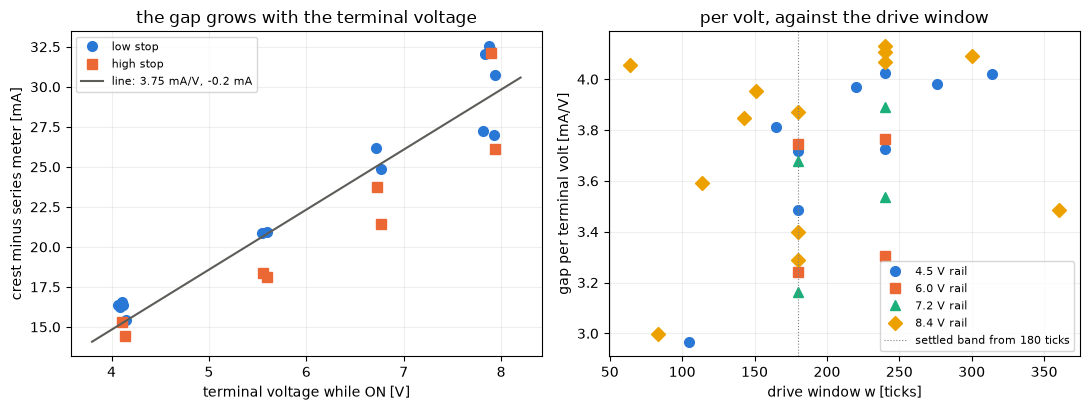

In [23]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
for i, stop in enumerate(["low", "high"]):
    g = BAND[BAND["stop"] == stop]
    a1.plot(g["vterm"], g["gap_mA"], MARK[i], color=PAL[i], ms=7, ls="none", label=f"{stop} stop")
k = np.polyfit(BAND["vterm"], BAND["gap_mA"], 1)
vv = np.linspace(3.8, 8.2, 2)
a1.plot(vv, np.polyval(k, vv), color=PAL[7], lw=1.5, label=f"line: {k[0]:.2f} mA/V, {k[1]:+.1f} mA")
a1.set_xlabel("terminal voltage while ON [V]")
a1.set_ylabel("crest minus series meter [mA]")
a1.set_title("the gap grows with the terminal voltage")
for i, rail in enumerate(sorted(G["rail"].unique())):
    g = G[(G["rail"] == rail) & (G["D"] <= 0.30)]
    a2.plot(g["w"], g["mA_per_V"], MARK[i], color=PAL[i], ms=7, ls="none", label=f"{rail} V rail")
a2.axvline(180, color="grey", lw=0.8, ls=":", label="settled band from 180 ticks")
a2.set_xlabel("drive window w [ticks]")
a2.set_ylabel("gap per terminal volt [mA/V]")
a2.set_title("per volt, against the drive window")
for a in (a1, a2):
    a.grid(alpha=0.2)
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at:** left, every settled-band hold's crest minus the series meter
against the terminal voltage, coloured by stop, with a straight line through them. Right, every
hold's gap per terminal volt against its drive window, coloured by rail, with the 180-tick
edge of the settled band dotted. The left panel is the evidence that the gap scales with the voltage on
the motor. The right one shows that the per-volt figure is flat from 180 ticks up and wanders
below it.

**Claim 1, the gap is real motor ON-only current: likely, on the old network only.** It needs
the motor, it is gone at 100%, and the chain reads a resistor within 0.6% (section 9.6.2).
Other explanations still alive: the crest instant sitting late on the commutation ripple
(that would need about 3 us of timing error, and the scan gives about 0.3 us), the meter
under-reading the ripple (but the gap tracks the voltage, not the ripple), or the chain
answering a motor-shaped load differently from a resistor. Which circuit carries it is
unknown. The test that would decide it is a scope on a ~1 ohm series sense resistor in the
motor lead against the crest, in the same hold. A real current cannot move with the amplifier
network, so the gap measured again on the final network is the second test.

#### 9.6.2 The chain on a 15.3 ohm resistor

Four runs, two rails, eleven windows each.

In [24]:
RAILS = sorted(next(iter(RLAD.values())))
PCTS = sorted(next(iter(RLAD.values()))[RAILS[0]])
rows, mrows, step = [], [], []
for run in RUNS:
    for rail in RAILS:
        g = RLAD[run][rail]
        # The plateau per vbus count: the late-ON level of the D 15 bursts only (A15), or of
        # D 15 and 25 pooled (A25). vbus (slot 5) closes 291 ticks after the crest, inside the
        # window only at D 25, so D 25 normalises by a loaded rail and every shorter window
        # by an unloaded one.
        lvl = lambda ds: [sb.late_level(b) / b["vb"] for p in ds for b in g[p] if b["fit"]]
        P15, P25, P25only = np.mean(lvl([15.0])), np.mean(lvl([15.0, 25.0])), np.mean(lvl([25.0]))
        step.append(dict(run=run, rail=rail, step_pct=(P15 / P25only - 1) * 100))
        for p in PCTS:
            w = p * 12
            per = [float(np.mean(b["crest"])) / b["vb"] for b in g[p] if len(b["crest"])]
            # B: the residual at the crest sample against each burst's own late line, from
            # the D 10/15/25 bursts, whose windows reach past tau 136. No vbus anywhere.
            eB = [r * 100 for q in (10.0, 15.0, 25.0) for b in g[q]
                  if (r := sb.resid_at(b, w + sb.CREST)) is not None] if w + sb.CREST < sb.FIT_FROM else []
            rows.append(dict(run=run, rail=rail, w=w, n=len(per),
                             A25=np.mean([(x / P25 - 1) * 100 for x in per]),
                             A15=np.mean([(x / P15 - 1) * 100 for x in per]),
                             B=np.mean(eB) if eB else np.nan))
        # The motor floor's estimator run on the resistor, where the truth is flat: R(w) from
        # the D 6/8/10 crests, linear in w and extrapolated below 72, over the residual at
        # w + 31 (within 2 ticks) from the D 8/10/15 bursts.
        R = {q * 12: np.mean([x for b in g[q] for x in b["crest"]]) for q in (6.0, 8.0, 10.0)}
        ws = sorted(R)
        pool = [b for q in (8.0, 10.0, 15.0) for b in g[q] if b["fit"]]
        for w in sb.WS:
            a_, b_ = (ws[0], ws[1]) if w <= ws[1] else (ws[1], ws[2])
            Rw = R[a_] + (R[b_] - R[a_]) * (w - a_) / (b_ - a_)
            res_ = np.mean([x for b in pool for t, x in b["resid"] if abs(t - (w + sb.CREST)) <= 2])
            mrows.append(dict(run=run, rail=rail, w=w, M=res_ / (Rw - res_) * 100))
RCH = pd.DataFrame(rows)
STEP = pd.DataFrame(step)
print("vbus normalisation step, plateau per vbus at D 15 over D 25, %, per run:")
print(STEP.pivot(index="rail", columns="run", values="step_pct").round(2).assign(
    mean=lambda x: x.mean(axis=1), SD=lambda x: x.iloc[:, :4].std(axis=1)).round(2).to_string())
T2 = RCH.groupby(["rail", "w"]).agg(A25=("A25", "mean"), A25_SD=("A25", "std"), A15=("A15", "mean"),
                                    A15_SD=("A15", "std"), B=("B", "mean"), B_SD=("B", "std")).reset_index()
MRES = pd.DataFrame(mrows).groupby(["rail", "w"])["M"].agg(["mean", "std"]).reset_index()
print("\nraw chain error at the crest sample, %, mean and SD over the 4 runs:")
print(T2.pivot(index="w", columns="rail").swaplevel(axis=1).sort_index(axis=1).round(2).to_string())
# w 300 is D 25, the one window whose own vbus sample closes inside the ON window; it is
# the normalisation step above, not the chain, so the grading runs from 48 to 180.
w48 = T2[(T2["w"] >= 48) & (T2["w"] <= 180)]
print(f"\nw 48 to 180: worst |A15| {w48['A15'].abs().max():.2f}%, worst |B| {w48['B'].abs().max():.2f}%, "
      f"worst |A25| {w48['A25'].abs().max():.2f}%; largest across-run SD {w48[['A25_SD', 'A15_SD', 'B_SD']].max().max():.2f}%")
print(f"A15 minus A25: {(w48['A15'] - w48['A25']).min():.2f} to {(w48['A15'] - w48['A25']).max():.2f}%")
both = w48.dropna(subset=["B"])
print(f"A15 against B where both exist: largest difference {(both['A15'] - both['B']).abs().max():.2f}%")
cmp = MRES.merge(T2, on=["rail", "w"])
print(f"motor estimator on the resistor against B, w 48-96: largest difference {(cmp['mean'] - cmp['B']).abs().max():.2f}%")

vbus normalisation step, plateau per vbus at D 15 over D 25, %, per run:
run   rep0  rep1  rep2  rep3  mean    SD
rail                                    
4.5  -1.48 -1.54 -1.69 -1.61 -1.58  0.09
8.4  -1.31 -1.38 -1.39 -1.41 -1.37  0.04

raw chain error at the crest sample, %, mean and SD over the 4 runs:
rail    4.5                                   8.4                                
        A15 A15_SD   A25 A25_SD     B  B_SD   A15 A15_SD   A25 A25_SD     B  B_SD
w                                                                                
42.0  -1.32   0.17 -2.09   0.18 -0.92  0.03 -1.71   0.12 -2.39   0.13 -1.80  0.04
48.0  -0.50   0.05 -1.28   0.06 -0.25  0.01 -0.40   0.12 -1.09   0.10 -0.49  0.05
54.0  -0.10   0.08 -0.89   0.06  0.10  0.03  0.26   0.01 -0.43   0.02  0.13  0.02
60.0   0.03   0.14 -0.76   0.12  0.26  0.03  0.48   0.02 -0.22   0.02  0.42  0.04
66.0   0.08   0.08 -0.71   0.05  0.29  0.05  0.60   0.03 -0.09   0.02  0.51  0.03
72.0   0.14   0.12 -0.65   0.10  0.28

From 48 to 180 ticks, A15 and B read within 0.60% and 0.52%, and the SD across the four runs is at
most 0.17%. A25 reads 0.69 to 0.79% under A15 at every window. That is the vbus
normalisation, not the chain. Slot 5 of the scan, which reads the rail, closes 291 ticks
after the crest and lands inside the ON window only at D 25%. So D 25% normalises by a
loaded rail and every shorter window by an unloaded one, and the plateau per vbus count steps
by 1.58% (4.5 V) and 1.37% (8.4 V) between them. The same artefact is why w 300 reads +1.1
to +1.4% on A15. A15 and B agree within 0.24%, and TEL's own ungained reading agrees with
A15 within 0.10% (next section). At 42 ticks every route reads low, -0.9 to -2.4%, which
is the sign the wirewound part's L/R lag predicts and not one this data can split from a
chain lag.

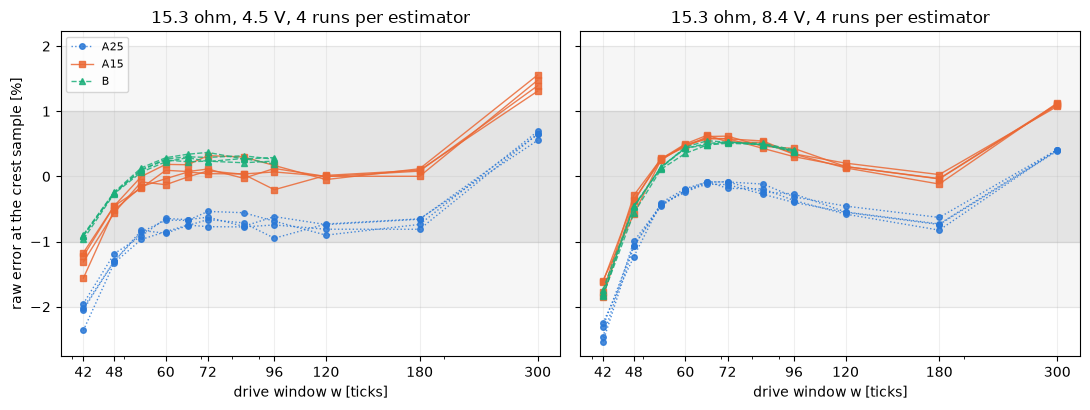

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, rail in zip(axes, RAILS):
    for j, (est, ls) in enumerate([("A25", ":"), ("A15", "-"), ("B", "--")]):
        for i, run in enumerate(RUNS):
            d = RCH[(RCH["rail"] == rail) & (RCH["run"] == run)].dropna(subset=[est])
            ax.plot(d["w"], d[est], MARK[j] + ls, color=PAL[j], ms=4, lw=1, alpha=0.85,
                    label=est if i == 0 else None)
    ax.axhspan(-1, 1, color="grey", alpha=0.15)
    ax.axhspan(-2, 2, color="grey", alpha=0.07)
    ax.set_xscale("log")
    ax.set_xticks([42, 48, 60, 72, 96, 120, 180, 300])
    ax.set_xticklabels(["42", "48", "60", "72", "96", "120", "180", "300"])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel("drive window w [ticks]")
    ax.set_title(f"15.3 ohm, {rail} V, 4 runs per estimator")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("raw error at the crest sample [%]")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at:** the raw error at the firmware's crest sample on the resistor, one
line per run and estimator, per rail, against the drive window on a log axis. The dark band is
+/-1% and the light one +/-2%. A25 sits low by its vbus step, A15 and B overlap, and the four
runs of each are hard to tell apart.

**Claim 4a, the chain reads a resistor within 2% from 48 ticks: confirmed, for positive duty on
this load,** four runs including a power cycle. It is within 0.6% by A15 and B (1.3% by A25).
A wirewound L/R could hide a small positive chain bump at $w \le 48$, and the reverse leg is
untested.

#### 9.6.3 What the firmware reads with the shipped settle gain

`i_settle_gain` was fitted on the 100 pF network. On this one it multiplies an error that is
already near zero.

In [26]:
SETTLE = minduty.settle_gain()                           # the shipped table, read from the board file
gain_at = lambda w: minduty.settle_gain_at(w, SETTLE)
band_of = lambda w: (max(int(w) - SETTLE[0], 0) >> 3) if (max(int(w) - SETTLE[0], 0) >> 3) < len(SETTLE[1]) else None
rows = []
for run, cap in RUNS.items():
    for rail in RAILS:
        lv = {}
        for p in PCTS:
            if p * 12 < B2A.floor_i_ticks:               # under the 64-tick floor i_hat reads 0
                continue
            t = pd.read_csv(RES.path / "ladder" / cap / f"tel_{rail:g}_{p:g}.csv.gz")
            goal = round(p / 100 * 32768)
            t = t[t["phase"].isin(["settle", "burst_c0", "post", "pre_arm"]) & ((t["duty_applied_q15"] - goal).abs() <= 1)]
            lv[p] = ((t["current"] - t["bias"]).mean(), t["i_hat"].mean(), t["vbus_raw"].mean(), len(t))
        P = lv[15.0][0] / lv[15.0][2]                    # the D 15 hold per vbus count, as A15
        for p, (raw, ih, vb, n) in lv.items():
            rows.append(dict(run=run, rail=rail, w=p * 12, n=n, g_eff=ih / raw, g_ship=gain_at(p * 12),
                             raw_err=(raw / vb / P - 1) * 100, fw_err=(ih / vb / P - 1) * 100))
TEL = pd.DataFrame(rows)
T3 = TEL.groupby(["rail", "w"]).agg(rows=("n", "sum"), g_eff=("g_eff", "mean"), g_ship=("g_ship", "first"),
                                    raw_err=("raw_err", "mean"), fw_err=("fw_err", "mean"), fw_SD=("fw_err", "std")).reset_index()
print("firmware i_hat on the resistor with the shipped table, % against the D 15 hold, 4 runs:")
print(T3.round(3).to_string(index=False))
print(f"\ni_hat / (current - bias) against the shipped band: largest difference {(T3['g_eff'] - T3['g_ship']).abs().max():.4f}")
tc = T3[T3["w"] <= 180].merge(T2, on=["rail", "w"])
print(f"TEL's own ungained error against the bursts' A15, w 66 to 180: largest difference {(tc['raw_err'] - tc['A15']).abs().max():.2f}%")
# Under the floor the firmware reads nothing; what it would read is the raw error times the band.
low = T2[(T2["w"] >= 48) & (T2["w"] < B2A.floor_i_ticks)].copy()
low["fw_err"] = ((1 + low["A15"] / 100) * low["w"].map(gain_at) - 1) * 100
FW = pd.concat([low.assign(route="A15 x gain")[["rail", "w", "fw_err", "route"]],
                T3.assign(route="TEL i_hat")[["rail", "w", "fw_err", "route"]]])
print("\nthe firmware's reading by window, %:")
print(FW.pivot_table(index="rail", columns="w", values="fw_err").round(1).to_string())

firmware i_hat on the resistor with the shipped table, % against the D 15 hold, 4 runs:
 rail     w  rows  g_eff  g_ship  raw_err  fw_err  fw_SD
  4.5  66.0   975  1.036   1.035    0.010   3.637  0.083
  4.5  72.0   981  1.026   1.027    0.039   2.678  0.050
  4.5  84.0   977  1.021   1.021    0.054   2.155  0.078
  4.5  96.0   975  1.016   1.015    0.037   1.687  0.031
  4.5 120.0   960  1.010   1.010   -0.003   0.990  0.044
  4.5 180.0   955  1.003   1.002    0.000   0.333  0.001
  4.5 300.0   966  1.000   1.000    1.532   1.533  0.066
  8.4  66.0   977  1.035   1.035    0.599   4.077  0.063
  8.4  72.0   978  1.026   1.027    0.599   3.213  0.099
  8.4  84.0   980  1.021   1.021    0.554   2.640  0.054
  8.4  96.0   986  1.016   1.015    0.416   1.981  0.059
  8.4 120.0   980  1.010   1.010    0.209   1.253  0.079
  8.4 180.0   980  1.002   1.002    0.000   0.174  0.001
  8.4 300.0   978  1.000   1.000    1.104   1.106  0.049

i_hat / (current - bias) against the shipped band: large

`i_hat / (current - bias)` equals the shipped band at every window to 0.0015, so the firmware
applies the table it ships. The table now over-reads the resistor by 3.6% (4.5 V) and 4.1% (8.4 V)
at the 66-tick rung, the first one over the 64-tick floor, and by 1.0 to 1.3% as late as 120
ticks. Under the floor, where the firmware reports nothing, the same table would read +4.8 to +8.0%.

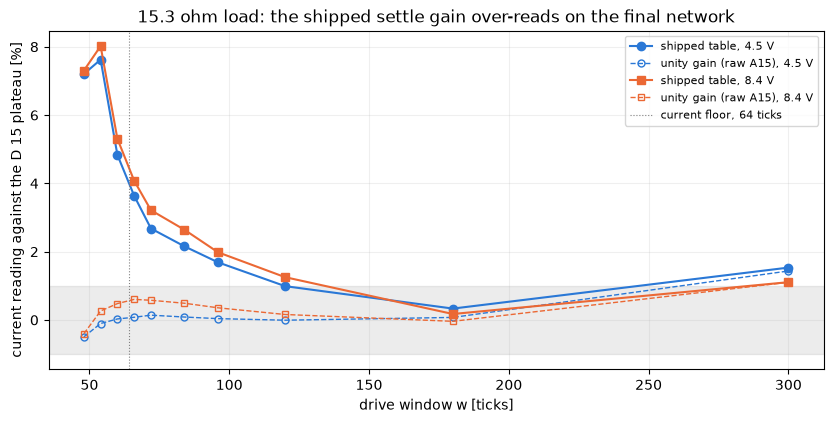

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for i, rail in enumerate(RAILS):
    d = FW[FW["rail"] == rail].groupby("w")["fw_err"].mean()
    ax.plot(d.index, d.values, MARK[i] + "-", color=PAL[i], ms=6, lw=1.5, label=f"shipped table, {rail} V")
    u = T2[(T2["rail"] == rail) & (T2["w"] >= 48)]
    ax.plot(u["w"], u["A15"], MARK[i] + "--", color=PAL[i], ms=5, lw=1, mfc="none", label=f"unity gain (raw A15), {rail} V")
ax.axhspan(-1, 1, color="grey", alpha=0.15)
ax.axvline(B2A.floor_i_ticks, color="grey", lw=0.8, ls=":", label=f"current floor, {B2A.floor_i_ticks} ticks")
ax.set_xlabel("drive window w [ticks]")
ax.set_ylabel("current reading against the D 15 plateau [%]")
ax.set_title("15.3 ohm load: the shipped settle gain over-reads on the final network")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** the firmware's reading on the resistor against the D 15% point
per vbus count, with the shipped table (solid, TEL `i_hat` from 66 ticks, A15 times the band
under it) and with no gain at all (dashed, A15), per rail. The grey band is +/-1%, and the
dotted line is the 64-tick floor. The shipped table lifts every window it touches. Unity sits
inside the band from 48 ticks.

**The shipped table over-reads: confirmed, for positive duty.** A table that reads the
resistor back to zero is $q_{15} = 32768/(1 + E)$ per 8-tick band:

In [28]:
# q15 = 32768 / (1 + E): the table that would read the resistor's raw error back to zero.
rows = []
for b in range(len(SETTLE[1])):
    lo = SETTLE[0] + 8 * b
    r = dict(band=b, ticks=f"{lo}-{lo + 7}", shipped_q15=SETTLE[1][b])
    for rail in RAILS:
        x = T2[(T2["rail"] == rail) & (T2["w"] >= lo) & (T2["w"] <= lo + 7)]
        r[f"A15 {rail} V"] = round(32768 / (1 + x["A15"].mean() / 100)) if len(x) else None
        r[f"B {rail} V"] = round(32768 / (1 + x["B"].mean() / 100)) if len(x) and x["B"].notna().any() else None
    rows.append(r)
REFIT = pd.DataFrame(rows)
fit_cols = [c for c in REFIT if c.startswith(("A15", "B "))]
meas = REFIT[REFIT[fit_cols].notna().any(axis=1)]
from48 = meas[meas["band"] >= 1][fit_cols].stack()
print(f"bands with a rung: {meas['band'].tolist()}; with none: {REFIT[~REFIT.index.isin(meas.index)]['band'].tolist()}")
print(f"refit from band 1 (w >= 48): unity within {(from48 / 32768 - 1).abs().max() * 100:.2f}%; "
      f"band 0: {meas[meas['band'] == 0][fit_cols].stack().min() / 32768:.3f} to {meas[meas['band'] == 0][fit_cols].stack().max() / 32768:.3f}")
REFIT

bands with a rung: [0, 1, 2, 3, 4, 5, 7, 10, 17]; with none: [6, 8, 9, 11, 12, 13, 14, 15, 16, 18, 19, 20]
refit from band 1 (w >= 48): unity within 0.60%; band 0: 1.009 to 1.018


,band,ticks,shipped_q15,A15 4.5 V,B 4.5 V,A15 8.4 V,B 8.4 V
0,0,40-47,37138,33205.0,33072.0,33338.0,33368.0
1,1,48-55,35303,32867.0,32793.0,32791.0,32826.0
2,2,56-63,34342,32758.0,32684.0,32612.0,32632.0
3,3,64-71,33918,32742.0,32674.0,32572.0,32603.0
4,4,72-79,33643,32722.0,32676.0,32580.0,32598.0
5,5,80-87,33470,32740.0,32681.0,32608.0,32607.0
6,6,88-95,33374,NaN,NaN,NaN,NaN
7,7,96-103,33259,32755.0,32688.0,32652.0,32640.0
8,8,104-111,33213,NaN,NaN,NaN,NaN
9,9,112-119,33156,NaN,NaN,NaN,NaN


Every band with a rung from 48 ticks refits to unity within 0.60%, across both rails and both
estimators. Band 0 (40 to 47
ticks) refits to 1.009 to 1.018, where the wirewound lag and the chain cannot be told apart.
Bands 6, 8, 9 and 11 up have no rung. A flat unity table is **likely** good to 1% and **not yet
known** to 0.5%. Section 9.7 lists what the hands-on ladder has to add before a firmware change.

#### 9.6.4 The motor floors

Every network the bench ran, scored with the same estimator. The bootstrap resamples bursts
inside each hold, 300 times.

In [29]:
TAUS = (58, 66, 74, 82, 90, 98, 106)
rows, CURVES = [], {}
for name in SESS:
    for rail, (bs, dropped) in sorted(FLOOR[name].items()):
        r = sb.score(bs)
        bt = sb.boot(bs) if r["E"] else None
        st_ = {stop: sb.score([b for b in bs if b["stop"] == stop]) for stop in ("low", "high")}
        CURVES[(name, rail)] = r
        rows.append(dict(set=name, rail=rail, n_fit=r["n"], dropped=len(dropped), late=r["late"],
                         floor2=r["floors"][2], floor1=r["floors"][1],
                         boot2=f"{bt['f2'][0]:.0f}-{bt['f2'][1]:.0f}" if bt else "",
                         boot1=f"{bt['f1'][0]:.0f}-{bt['f1'][1]:.0f}" if bt else "",
                         b2lo=bt["f2"][0] if bt else np.nan, b2hi=bt["f2"][1] if bt else np.nan,
                         e48_boot_sd=bt["e48_sd"] if bt else np.nan,
                         **{f"E{w}": r["E"](w) if r["E"] else np.nan for w in sb.WS},
                         **{f"E48_{s}": st_[s]["E"](48) if st_[s]["E"] else np.nan for s in st_},
                         **{f"r{t}": sb.at(r["c"], t) for t in TAUS},
                         **{f"r{t}_{s}": sb.at(st_[s]["c"], t) for s in st_ for t in TAUS}))
MF = pd.DataFrame(rows)
for t in TAUS:
    MF[f"p{t}"] = MF[f"r{t}"] / MF["late"] * 100          # residual in % of the late-ON level
show = MF[["set", "rail", "dropped", "floor2", "boot2", "floor1", "boot1", "E48", "e48_boot_sd", "E56", "E64", "E72", "p74"]]
print("motor floors (ticks, 2% and 1%, with the 90% burst-bootstrap range), E(w) %, residual at tau 74 in % of late ON:")
print(show.round(1).to_string(index=False))

motor floors (ticks, 2% and 1%, with the 90% burst-bootstrap range), E(w) %, residual at tau 74 in % of late ON:
     set  rail  dropped  floor2 boot2  floor1  boot1  E48  e48_boot_sd  E56  E64  E72  p74
 caps-in   4.5        1    82.0 82-84    86.0  84-98  5.4          0.5 17.8  5.1 -3.8 -2.0
 caps-in   8.4        0    74.0 74-74    92.0  92-94 10.8          0.4  6.6  7.5  2.6 11.8
caps-out   4.5        1    54.0 52-56    60.0  56-70  2.9          0.5  1.1  0.3  0.2  2.2
caps-out   8.4        1    70.0 68-70    76.0  74-78 19.1          0.8  7.1  2.9  1.2  7.5
    ci22   4.5        0    52.0 50-62    74.0  54-82  3.2          0.7  0.5  1.0  1.0  3.2
    ci22   8.4        0    64.0 64-64    72.0  70-72  8.6          0.3  4.0  1.8  0.8  7.0
    ci47   4.5        0    52.0 48-58    66.0  54-82  3.1          0.8  1.3  1.0  0.9  2.4
    ci47   8.4        1    66.0 64-66    72.0  70-74 11.8          0.9  5.0  2.1  0.8  7.1
   cm1k5   4.5        0    42.0 40-46    76.0  48-78  0.3          0

caps-in is the old network. On the final network (cm1k5, m1, m2, m3) the 2% floor sits between
42 and 58 ticks at both rails, and $E(48)$ at 8.4 V sits at +4.1 to +5.8%. The bootstrap ranges are
not a substitute for repeats. At 8.4 V the burst bootstrap gives $E(48)$ an SD of 0.2 to 0.3% inside
each session, while the three repeats spread by 0.8%, so the session spread is the error bar.
The repeat gate below was set before the m1 to m3 runs: each rail's 2% floor has to span 8
ticks or less, and each run's residual at $\tau = 58$ has to sit within 20% of the three-run
mean.

In [30]:
REP = MF[MF["set"].isin(["m1", "m2", "m3"])]
GATE = {}
for rail, d in REP.groupby("rail"):
    dev = (d["r58"] / d["r58"].mean() - 1) * 100
    span = d["floor2"].max() - d["floor2"].min()
    GATE[rail] = dict(floors2=d["floor2"].tolist(), mean2=d["floor2"].mean(), sd2=d["floor2"].std(), worst2=d["floor2"].max(),
                      floors1=d["floor1"].tolist(), worst1=d["floor1"].max(), e48=d["E48"].tolist(),
                      e48_mean=d["E48"].mean(), e48_sd=d["E48"].std(), span=span, dev=dev.tolist(), r98=d["r98"].tolist(),
                      ok=span <= 8 and (dev.abs() <= 20).all())
    print(f"{rail} V m1-m3: 2% floor {d['floor2'].tolist()} mean {d['floor2'].mean():.1f} SD {d['floor2'].std():.1f} "
          f"worst {d['floor2'].max():.0f} span {span:.0f} | 1% floor {d['floor1'].tolist()} worst {d['floor1'].max():.0f} | "
          f"E(48) {[round(x, 1) for x in d['E48']]} mean {d['E48'].mean():.1f} SD {d['E48'].std():.1f} | "
          f"tau-58 residual off the mean {[round(x) for x in dev]}% | tau-98 residual {[round(x, 1) for x in d['r98']]} counts "
          f"| gate {'REPEATABLE' if GATE[rail]['ok'] else 'NOT repeatable'}")
cm = MF[MF["set"] == "cm1k5"].set_index("rail")
print(f"cm1k5 at 4.5 V: 2% floor {cm.loc[4.5, 'floor2']:.0f}, tau-98 residual {cm.loc[4.5, 'r98']:+.1f} counts")

4.5 V m1-m3: 2% floor [54.0, 46.0, 54.0] mean 51.3 SD 4.6 worst 54 span 8 | 1% floor [84.0, 82.0, 62.0] worst 84 | E(48) [3.4, 0.8, 2.3] mean 2.2 SD 1.3 | tau-58 residual off the mean [12, -7, -5]% | tau-98 residual [0.9, 0.3, 0.6] counts | gate REPEATABLE
8.4 V m1-m3: 2% floor [58.0, 54.0, 54.0] mean 55.3 SD 2.3 worst 58 span 4 | 1% floor [62.0, 58.0, 58.0] worst 62 | E(48) [5.8, 4.5, 4.3] mean 4.9 SD 0.8 | tau-58 residual off the mean [4, -1, -3]% | tau-98 residual [0.5, -0.3, -0.3] counts | gate REPEATABLE
cm1k5 at 4.5 V: 2% floor 42, tau-98 residual -0.9 counts


**The motor floor on the final network: repeatable by the pre-registered gate, at the
limit at 4.5 V.** The 2% floor is 51.3 ticks, SD 4.6, worst 54 at 4.5 V, and 55.3, SD 2.3, worst
58 at 8.4 V, both under the shipped 64. The 1% floor is 58 to 62 at 8.4 V but 62 to 84 at 4.5 V,
so the 4.5 V 1% floor is not stable. What sets it is the late tail. At $\tau = 98$ the 4.5 V
residual is +0.3 to +0.9 counts in m1 to m3 and -0.9 in cm1k5, so cm1k5's 42-tick floor was a
lucky session rather than the network.

With the shipped table, a stalled MG90 at the 64-tick floor would read about 4% high from the
chain's over-gain (section 9.6.3) plus $E(64)$, 0.0 to +0.6% at 8.4 V on the final network, before
the ON-only gap on top.

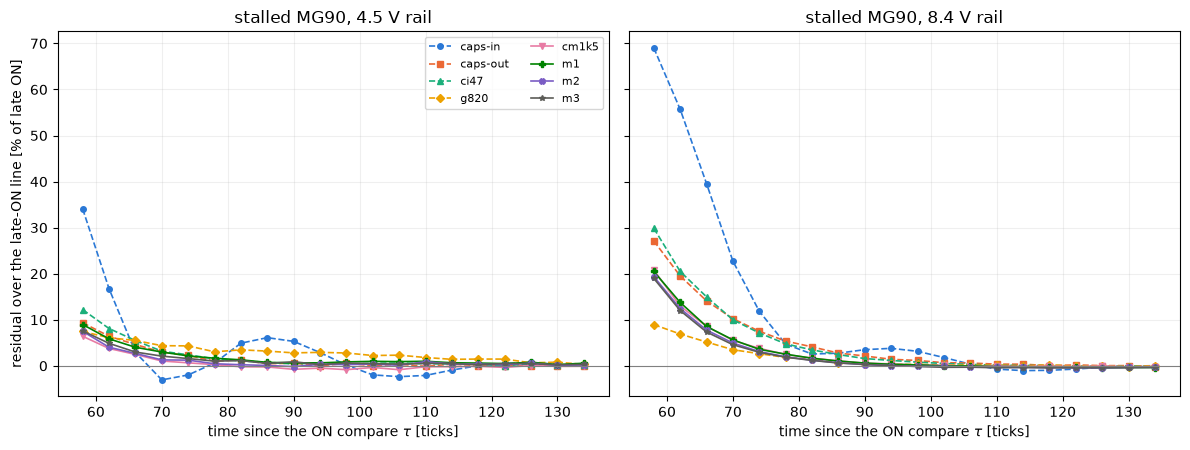

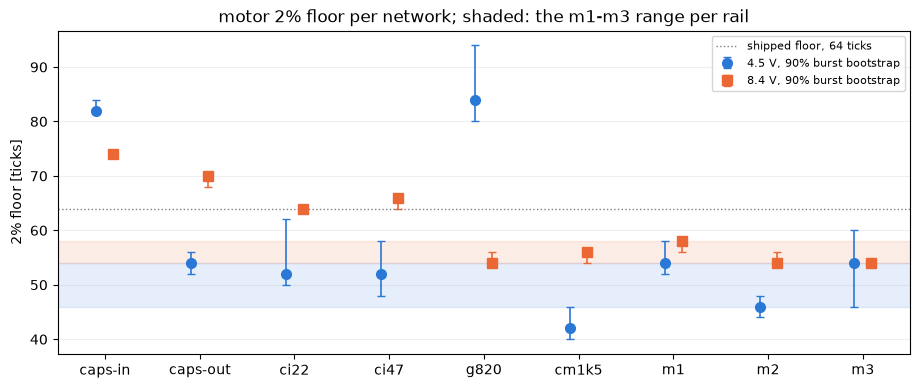

In [31]:
NETS = ["caps-in", "caps-out", "ci22", "ci47", "g820", "cm1k5", "m1", "m2", "m3"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, rail in zip(axes, RAILS):
    for i, s in enumerate(["caps-in", "caps-out", "ci47", "g820", "cm1k5", "m1", "m2", "m3"]):
        c = CURVES[(s, rail)]["c"]
        late = MF[(MF["set"] == s) & (MF["rail"] == rail)]["late"].iloc[0]
        x = np.array(sorted(k for k in c if 56 <= k <= 134))
        ax.plot(x, [c[k] / late * 100 for k in x], marker=MARK[i % 8], color=PAL[i % 8], ms=4, lw=1.2,
                ls="-" if s in FINAL else "--", label=s)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel(r"time since the ON compare $\tau$ [ticks]")
    ax.set_title(f"stalled MG90, {rail} V rail")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("residual over the late-ON line [% of late ON]")
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.2))
for i, rail in enumerate(RAILS):
    d = MF[(MF["rail"] == rail) & MF["floor2"].notna()].set_index("set").loc[NETS]
    x = np.arange(len(d)) + (i - 0.5) * 0.18
    ax.errorbar(x, d["floor2"], yerr=[d["floor2"] - d["b2lo"], d["b2hi"] - d["floor2"]], fmt=MARK[i],
                color=PAL[i], ms=7, capsize=3, lw=1.2, label=f"{rail} V, 90% burst bootstrap")
    ax.axhspan(REP[REP["rail"] == rail]["floor2"].min(), REP[REP["rail"] == rail]["floor2"].max(), color=PAL[i], alpha=0.12)
ax.axhline(B2A.floor_i_ticks, color="grey", lw=1, ls=":", label=f"shipped floor, {B2A.floor_i_ticks} ticks")
ax.set_xticks(np.arange(len(NETS)))
ax.set_xticklabels(NETS)
ax.set_ylabel("2% floor [ticks]")
ax.set_title("motor 2% floor per network; shaded: the m1-m3 range per rail")
ax.grid(alpha=0.2, axis="y")
ax.legend(fontsize=8)
plt.show()

**What you are looking at:** top, the pooled residual over each burst's late-ON line, in
percent of the late-ON level, against the time since the ON compare, one line per network
(dashed for the networks before the pull-ups), one panel per rail. The firmware samples at
$\tau = w + 31$, so a 48-tick window reads the curve at 79. Bottom, each network's 2% floor with
its burst-bootstrap range, the m1 to m3 spread shaded per rail, and the shipped floor dotted.
The pull-ups pull the 8.4 V curves down from the start. At 4.5 V only the earliest bins move.

**Which changes are levers.** A network change counts as a lever when it moves a quantity by
more than the final network's own session-to-session spread. With the final sessions'
mean $m$, SD $s$ and count $n$, a one-session network scores
$z = (q - m)/(s \sqrt{1 + 1/n})$, and $|z| \ge 2$ is the bar. The quantities are the residual
at $\tau$ = 58, 66 and 74 in percent of late ON, $E(48)$ and the 2% floor.

In [32]:
# Yardstick: the sessions on the final network (cm1k5, rev430, m1, m2, m3). For a quantity q
# of a one-session network X: z = (q_X - mean_final) / (SD_final sqrt(1 + 1/n_final)).
Q = ["p58", "p66", "p74", "E48", "floor2"]
LEV = {}
for rail, d in MF.groupby("rail"):
    d = d.set_index("set")
    fin = d.loc[[s for s in FINAL if s in d.index]]
    stats = {q: (fin[q].mean(), fin[q].std(), fin[q].notna().sum()) for q in Q}
    for s in ("caps-in", "caps-out", "ci22", "ci47", "g820"):
        for q in Q:
            m, sd, n = stats[q]
            LEV[(rail, s, q)] = (d.loc[s, q], (d.loc[s, q] - m) / (sd * np.sqrt(1 + 1 / n)))
    print(f"{rail} V final network ({', '.join(fin.index)}): " +
          ", ".join(f"{q} {stats[q][0]:.1f} SD {stats[q][1]:.2f} n {stats[q][2]}" for q in Q))
LEVERS = pd.DataFrame([{"rail": r, "network": s, "quantity": q, "value": v, "z": z} for (r, s, q), (v, z) in LEV.items()])
LEVERS.pivot_table(index=["rail", "network"], columns="quantity", values="z", sort=False)[Q].round(1)

4.5 V final network (cm1k5, rev430, m1, m2, m3): p58 7.9 SD 1.13 n 5, p66 3.4 SD 1.05 n 5, p74 1.7 SD 0.93 n 5, E48 1.7 SD 1.42 n 4, floor2 49.0 SD 6.00 n 4
8.4 V final network (cm1k5, rev430, m1, m2, m3): p58 18.8 SD 2.47 n 5, p66 7.7 SD 1.02 n 5, p74 3.3 SD 0.39 n 5, E48 4.7 SD 0.77 n 4, floor2 55.5 SD 1.91 n 4


quantity        p58   p66   p74   E48  floor2
rail network                                 
4.5  caps-in   21.2  -0.4  -3.6   2.3     4.9
     caps-out   1.2   1.0   0.5   0.7     0.7
     ci22       3.8   2.4   1.5   0.9     0.4
     ci47       3.5   1.8   0.6   0.8     0.4
     g820      -0.4   1.8   2.5   3.5     5.2
8.4  caps-in   18.5  28.5  20.1   7.1     8.6
     caps-out   3.1   5.8   9.9  16.7     6.8
     ci22       3.1   5.5   8.7   4.6     4.0
     ci47       4.1   6.5   9.0   8.2     4.9
     g820      -3.7  -2.2  -1.5  -0.5    -0.7

**Claim 2, the pull-ups cut the turn-on error: likely at 8.4 V. At 4.5 V only the earliest
residual moves.** ci47 is the same parts without the pull-ups. At 8.4 V it sits +4.1, +6.5 and
+9.0 sigma above the final network at $\tau$ = 58, 66 and 74, and its floor +4.9. At 4.5 V only
$\tau = 58$ clears the bar (+3.5), while $\tau = 74$ and the floor are under 1. This rests on one
ci47 session, and the rework that fitted the pull-ups also re-soldered JP1 and Ci1, so a side
effect of the rework is still alive. The test is the pull-ups off and on again in one session,
and a second common-mode level.

**Claim 3a, Ci1 0, 22 or 47 pF is not a lever: likely.** caps-out, ci22 and ci47 read 7.5, 7.0 and
7.1% at $\tau = 74$ at 8.4 V, within 0.5% of each other against a final-network SD of 0.39%. Their
8.4 V floors are 70, 64 and 66, 4 to 6 ticks apart against the final network's 1.9-tick SD, one session each, and
caps-out carries one whole low hold that reads high. A repeat of each would settle it.

**Claim 3b, Rg 820 against 430 is not a lever: likely that it does not help.** At 8.4 V only
$\tau = 58$ moves (-3.7), and $E(48)$ and the floor stay within 0.7 sigma. At 4.5 V it looks
worse, a floor of 84 (+5.2) and $E(48)$ of +7.3% (+3.5), with a positive late tail of its own.
That it hurts at 4.5 V is one session.

**The drop rule.** The same scoring with the earlier rule, which dropped a burst only when its
ON window read near zero:

In [33]:
# The earlier drop rule (ON window reads as zero against the hold's median crest, or a noisy
# OFF phase), for the rows where the choice of rule moves a number.
rows = []
for name in SESS:
    for rail, (k, dr) in sorted(FLOOR[name].items()):
        allb = k + dr
        by = defaultdict(list)
        for b in allb:
            by[(b["D"], b["stop"])].append(b)
        keepz = []
        for hold in by.values():
            ref = float(np.median([np.median(b["crest"]) for b in hold if len(b["crest"])]))
            keepz += [b for b in hold if not sb.zero_window(b, ref_crest=ref)]
        rz, rp = sb.score(keepz), CURVES[(name, rail)]
        if rp["E"] is None:
            continue
        m = MF[(MF["set"] == name) & (MF["rail"] == rail)].iloc[0]
        rows.append(dict(set=name, rail=rail, dropped_zero=len(allb) - len(keepz), dropped_phase=len(dr),
                         floor2_zero=rz["floors"][2], floor2_phase=rp["floors"][2], boot2_phase=m["boot2"],
                         E48_zero=rz["E"](48), E48_phase=rp["E"](48), E48_boot_sd=m["e48_boot_sd"]))
SENS = pd.DataFrame(rows)
SENS["E48_shift_in_sd"] = (SENS["E48_zero"] - SENS["E48_phase"]) / SENS["E48_boot_sd"]
moved = SENS[(SENS["floor2_zero"] != SENS["floor2_phase"]) | (SENS["E48_zero"] != SENS["E48_phase"])]
print("rows where the drop rule changes anything (E(48) shift in units of that row's burst-bootstrap SD):")
print(moved.round(1).to_string(index=False))

rows where the drop rule changes anything (E(48) shift in units of that row's burst-bootstrap SD):
    set  rail  dropped_zero  dropped_phase  floor2_zero  floor2_phase boot2_phase  E48_zero  E48_phase  E48_boot_sd  E48_shift_in_sd
caps-in   4.5             0              1           94            82       82-84       3.0        5.4          0.5             -4.4
   ci47   8.4             0              1           66            66       64-66      12.2       11.8          0.9              0.4
     m1   8.4             1              2           58            58       56-58       6.0        5.8          0.3              0.8
     m2   8.4             0              1           56            54       54-56       5.5        4.5          0.2              5.2


Only two rows move beyond their own bootstrap spread, caps-in at 4.5 V (the floor 94 to 82,
$E(48)$ by 2.4%) and m2 at 8.4 V ($E(48)$ by 1.0%, the floor
56 to 54). Each is one misfolded burst that the zero rule kept. Every other number above is the
same under either rule.

#### 9.6.5 The claims, together

Claim 4b is the last one. On the final network the motor reads $E(48)$ = +4.9% at 8.4 V, SD 0.8
over m1 to m3, where the resistor reads -0.49% (route B) at the same window. Halving the gain
(g820) leaves $E(48)$ at +4.3%. So the chain reading of a resistor is not what is left. The
leading candidate is the motor's turn-on charge. A chain non-linearity that only the motor's
edge excites is still alive, and so is the $E(48)$ extrapolation, which has only been checked
on the resistor. The decisive test is the resistor with 10 and 22 nF film caps across it on the
final network. The $E(48)$ shift has to scale with $C V$ and land on the motor's for a
$C_m$ of about 10 nF.

In [34]:
f84, f45 = GATE[8.4], GATE[4.5]
z = lambda r, s, q: LEV[(r, s, q)][1]
CLAIMS = pd.DataFrame([
    ["1", "the ON-only gap is real motor current",
     f"{GAP_PER_V[0]:.2f} +/- {GAP_PER_V[1]:.2f} mA/V over {len(BAND)} holds, {BAND['session'].nunique()} sessions; "
     f"open load {OPEN['crest_minus_trough_mA'].min():+.1f} to {OPEN['crest_minus_trough_mA'].max():+.1f} mA; 100% holds read the meter",
     "likely, caps-in network only", "scope on a series sense resistor in the motor lead; the gap re-measured on the final network"],
    ["2", "input pull-ups cut the turn-on error",
     f"ci47 vs final at 8.4 V: z {z(8.4, 'ci47', 'p58'):+.1f} / {z(8.4, 'ci47', 'p66'):+.1f} / {z(8.4, 'ci47', 'p74'):+.1f} at tau 58/66/74, "
     f"floor z {z(8.4, 'ci47', 'floor2'):+.1f}; 4.5 V tau 58 z {z(4.5, 'ci47', 'p58'):+.1f}, tau 74 z {z(4.5, 'ci47', 'p74'):+.1f}, floor z {z(4.5, 'ci47', 'floor2'):+.1f}",
     "likely at 8.4 V; at 4.5 V only the earliest residual moves (one ci47 session)", "pull-ups off and on in one session; a second common-mode level"],
    ["3a", "Ci1 0 / 22 / 47 pF is not a lever",
     "tau-74 residual " + " / ".join(f"{MF[(MF['set'] == s) & (MF['rail'] == 8.4)]['p74'].iloc[0]:.1f}" for s in ("caps-out", "ci22", "ci47"))
     + f"% at 8.4 V; 8.4 V floors " + " / ".join(f"{MF[(MF['set'] == s) & (MF['rail'] == 8.4)]['floor2'].iloc[0]:.0f}" for s in ("caps-out", "ci22", "ci47")),
     "likely (one session each)", "a repeat of each"],
    ["3b", "Rg 430 against 820 is not a lever",
     f"8.4 V: tau 58 z {z(8.4, 'g820', 'p58'):+.1f}, E(48) z {z(8.4, 'g820', 'E48'):+.1f}, floor z {z(8.4, 'g820', 'floor2'):+.1f}; "
     f"4.5 V floor z {z(4.5, 'g820', 'floor2'):+.1f}, E(48) z {z(4.5, 'g820', 'E48'):+.1f}",
     "likely that 820 does not help; that it hurts at 4.5 V is one session", "g820 repeated at 4.5 V"],
    ["4a", "the chain reads a resistor within 2% from 48 ticks",
     f"worst |A15| {w48['A15'].abs().max():.2f}%, |B| {w48['B'].abs().max():.2f}% over w 48-180 (|A25| {w48['A25'].abs().max():.2f}%); "
     f"across-run SD up to {w48[['A25_SD', 'A15_SD', 'B_SD']].max().max():.2f}%",
     "confirmed for positive duty on this load (4 runs)", "a reverse-duty ladder; a non-inductive load"],
    ["4b", "the remaining motor floor is the motor's turn-on charge",
     f"motor E(48) {f84['e48_mean']:+.1f} SD {f84['e48_sd']:.1f}% at 8.4 V (m1-m3) where the resistor's B reads "
     f"{T2[(T2['rail'] == 8.4) & (T2['w'] == 48)]['B'].iloc[0]:+.2f}%; g820 halves the gain and E(48) stays "
     f"{MF[(MF['set'] == 'g820') & (MF['rail'] == 8.4)]['E48'].iloc[0]:+.1f}%",
     "leading", "10 and 22 nF film caps across the resistor on the final network: the E(48) shift must scale with C x V"],
], columns=["#", "claim", "evidence (computed above)", "confidence", "what would falsify it"])
CLAIMS.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

#,claim,evidence (computed above),confidence,what would falsify it
1,the ON-only gap is real motor current,"3.73 +/- 0.31 mA/V over 23 holds, 3 sessions; open load +0.4 to +1.1 mA; 100% holds read the meter","likely, caps-in network only",scope on a series sense resistor in the motor lead; the gap re-measured on the final network
2,input pull-ups cut the turn-on error,"ci47 vs final at 8.4 V: z +4.1 / +6.5 / +9.0 at tau 58/66/74, floor z +4.9; 4.5 V tau 58 z +3.5, tau 74 z +0.6, floor z +0.4",likely at 8.4 V; at 4.5 V only the earliest residual moves (one ci47 session),pull-ups off and on in one session; a second common-mode level
3a,Ci1 0 / 22 / 47 pF is not a lever,tau-74 residual 7.5 / 7.0 / 7.1% at 8.4 V; 8.4 V floors 70 / 64 / 66,likely (one session each),a repeat of each
3b,Rg 430 against 820 is not a lever,"8.4 V: tau 58 z -3.7, E(48) z -0.5, floor z -0.7; 4.5 V floor z +5.2, E(48) z +3.5",likely that 820 does not help; that it hurts at 4.5 V is one session,g820 repeated at 4.5 V
4a,the chain reads a resistor within 2% from 48 ticks,"worst |A15| 0.60%, |B| 0.52% over w 48-180 (|A25| 1.28%); across-run SD up to 0.17%",confirmed for positive duty on this load (4 runs),a reverse-duty ladder; a non-inductive load
4b,the remaining motor floor is the motor's turn-on charge,motor E(48) +4.9 SD 0.8% at 8.4 V (m1-m3) where the resistor's B reads -0.49%; g820 halves the gain and E(48) stays +4.3%,leading,10 and 22 nF film caps across the resistor on the final network: the E(48) shift must scale with C x V


### 9.7 What is open, and the next experiment

- **The gap on the final network.** A few R1 holds with the series meter. A real motor current
  cannot move with the amplifier network, so a changed gap would point at the chain.
- **The known-capacitance fixture.** The 15.3 ohm load with 10 and 22 nF film caps on the final
  network. Turn-on charge predicts an $E(48)$ shift proportional to $C V$ that lands on the
  motor's at about 10 nF. A chain non-linearity predicts a shift that does not follow $C V$.
- **The 4.5 V late tail.** It sets the 4.5 V 1% floor and changes sign between sessions. The
  pull-ups off and on in one session also tests claim 2 at 4.5 V.
- **g820 at 4.5 V again**, to tell a real 4.5 V penalty from one bad session.
- **The settle gain.** Before a firmware change, the resistor ladder needs these additions:

| add | why |
|---|---|
| reverse drive (the OUT2 leg) | every resistor rung so far is positive duty, and the legs differ in node capacitance |
| a 100% rung per rail, same session | a switching-free scale reference to replace the vbus normalisation and its 0.7% step |
| a non-inductive load, or an LCR reading of the wirewound | to own the -1 to -1.8% at 42 to 48 ticks (load L/R against chain lag) |
| rungs every 4 ticks from 40 to 104 | two rungs per 8-tick band |
| the 2S pack as well as the DPS, at least 3 runs including a power cycle | the firmware's main supply, and the run spread |

The pass criterion to register before it runs: every rung from the floor within +/-1% of the
100% rung, both directions, both rails, every run.

The shipped 64-tick floor sits above the motor's worst 2% floor on both rails, so it stays.

## 10. What is open

The open items of the current-sense work on the final network are in section 9.7. These are
the grid's.

The open items of the current-sense work on the final network are in section 9.7. These are
the grid's.

The open items of the current-sense work on the final network are in section 9.7. These are
the grid's.

The open items of the current-sense work on the final network are in section 9.7. These are
the grid's.

The open items of the current-sense work on the final network are in section 9.7. These are
the grid's.

- **The tap-A route's blind spot.** On a board whose tap B reads the bias node, every
  forward terminal number includes the low side, 0.27 ohm on board D and 0.22 ohm (A side) on
  2A. The B side is assumed to match the A side. Board D's own two sides matched to 1.4%
  (0.448 V against 0.454 V at 1.69 A), but board D's island was the thing rev 2A redesigned, so
  that is an assumption on this dataset. Rv3 is repaired, and a 2A grid dataset with both taps
  reads the difference directly.
- **The live-bias trick holds on the 2A data.** Tap B rises 84 counts, 68 mV, at the forward
  100% rung and falls 5 counts at the reverse one. The bias node's 81 ohm source with leg A's
  0.82 mA into it predicts +67 mV, and with leg A pulling 34 uA out, -3 mV. A tap B that
  carried current of its own would not land on both. The direct check is still the meter on VB
  at Cb1 during a lap, which section 4.1 grades whenever the meter log has that row.
- **Board D's current direction effect.** The terminal difference reads 1.3% lower in reverse
  at the same shunt current, on the chip and on the meter alike (section 4.4). Rev 2A
  enters the shunt symmetrically from both low FETs, which the tap-A route cannot test. A
  two-tap 2A dataset tests it.
- **Small steps.** Every burst and rung here is the same 1.6 A step. The 2A edge is
  bandwidth-limited (section 8.3), but whether the slow tail behind it, the part that sets the
  1% floor, scales with the step needs the small-step burst set section 8.3 names.
- **The tail past the window.** The end of the 40% burst reads 0.56% above the 100% rung, and
  the 2A ladder's V/I sits 1 to 3% above its 100% rung at every partial duty (section 7).
  Something in the chain, or in the grid warming at 100%, moves slower than any window, so it
  sets the reference for a 0.5% floor rather than the floor.
- **A gap the servo did not count.** The rev-2A ladder session lost 416 samples, 26 whole
  frames, inside one rest segment (section 2.1), with `rows_dropped` at zero. Frames lost after
  the servo sent them are invisible to that counter, and so would be a stall in the stream that
  the counter does not count. The capture tool's own frame and CRC counts for that recording,
  set against the frames the tick span implies, say which side lost them.
- **The floor off the grid.** Every floor here rests on one 2S grid ladder. Notebook 16 carries the
  shipped floors and the MG90 ladder that verifies them on a motor.

The crest floor, the rest noise, the shunt settle and the Rs1 current check sit in the
`dev-v006-2A` registry entry. Next is a 2A grid session with both taps and the meter on DC laps, which closes the
items above that need tap B.